In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv(r"C:\Users\venka\Downloads\chronickidneydisease.csv")
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [2]:
  #LEts understand the null values and clean step by step

In [3]:
# Basic Libraries
import pandas as pd                    
import numpy as np                     
import matplotlib.pyplot as plt        
import seaborn as sns                  

# Preprocessing & Utilities
import warnings                        
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import LabelEncoder          
from sklearn.preprocessing import StandardScaler        

# Machine Learning Models
from sklearn.svm import SVC                              
from sklearn.linear_model import LogisticRegression      
from sklearn.ensemble import RandomForestClassifier      
from sklearn.neighbors import KNeighborsClassifier      
from sklearn.tree import DecisionTreeClassifier          

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model Saving
import joblib                                            


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
df.describe()


,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [6]:
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [7]:
df.duplicated().value_counts()


False    400
Name: count, dtype: int64

In [8]:
#Age is numeric and it has 9 null values lets see is it skewed has outliers..?

<Axes: xlabel='age'>

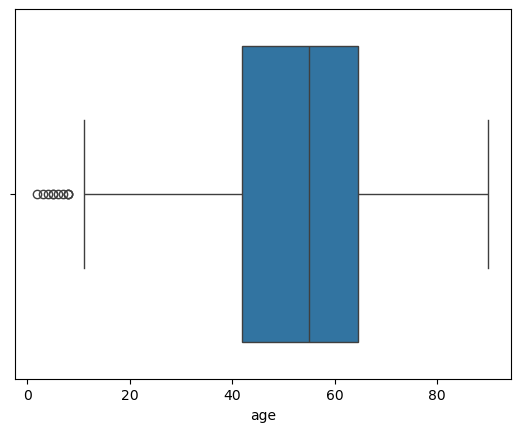

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df['age'])


<Axes: xlabel='age', ylabel='Count'>

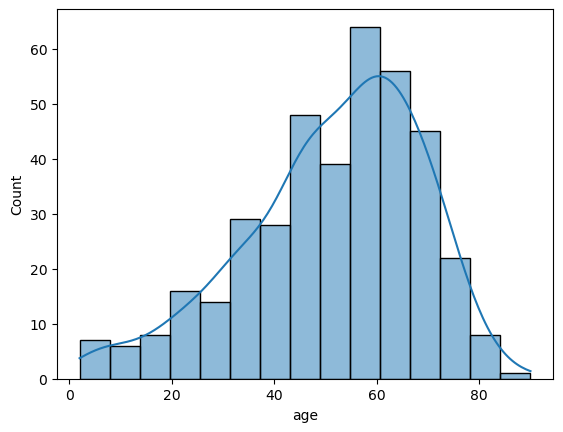

In [10]:
sns.histplot(df['age'] , kde=True)

In [11]:
df['age'] = df['age'].fillna(df['age'].median())


In [12]:
df['age'].isnull().sum()
df['age'].dtype

dtype('float64')

In [13]:
df.isnull().sum()

id                  0
age                 0
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

<Axes: xlabel='bp'>

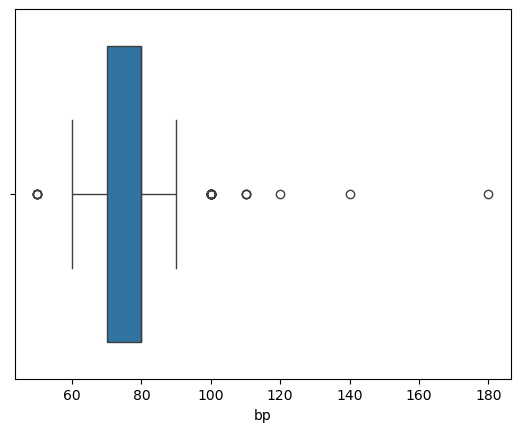

In [14]:
sns.boxplot(x=df['bp'])


<Axes: xlabel='bp', ylabel='Count'>

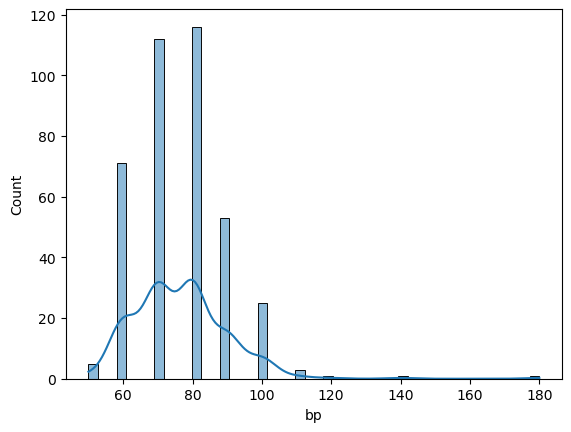

In [15]:
sns.histplot(df['bp'] , kde=True)

In [16]:
df['bp'].skew()

1.6054289569770592

In [19]:
df['bp'] = df['bp'].fillna(df['bp'].median())


In [20]:
df['bp'].isnull().sum()
df['bp'].dtype

dtype('float64')

In [21]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

<Axes: xlabel='sg'>

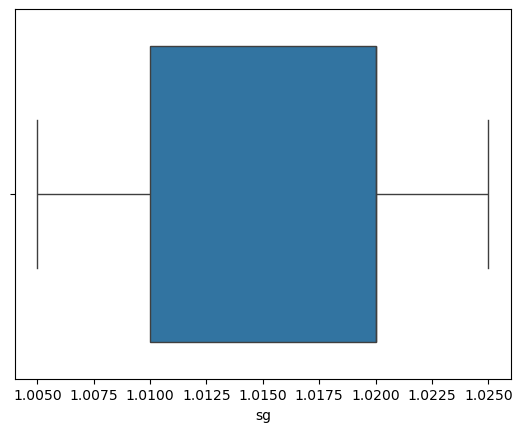

In [22]:
sns.boxplot(x=df['sg'])


<Axes: xlabel='sg', ylabel='Count'>

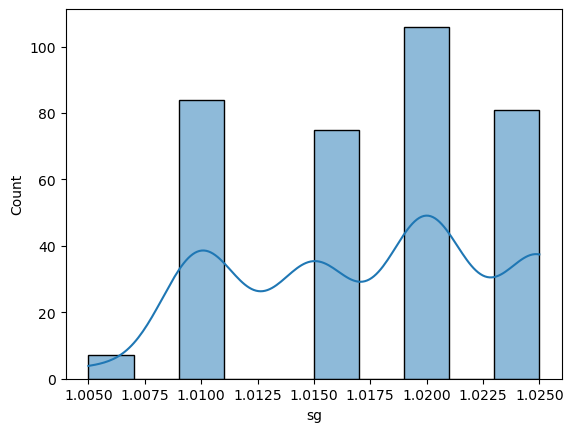

In [23]:
sns.histplot(df['sg'] , kde=True)

In [24]:
df['sg'].skew()

-0.1724437507086711

In [25]:
df['sg'] = df['sg'].fillna(df['sg'].median())


In [26]:
df['sg'].isnull().sum()
df['sg'].dtype

dtype('float64')

In [27]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [28]:
df['al'].value_counts()

al
0.0    199
1.0     44
2.0     43
3.0     43
4.0     24
5.0      1
Name: count, dtype: int64

<Axes: xlabel='al'>

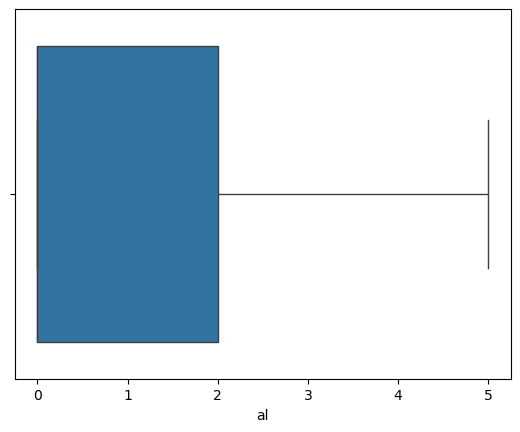

In [29]:
sns.boxplot(x=df['al'])


<Axes: xlabel='al', ylabel='Count'>

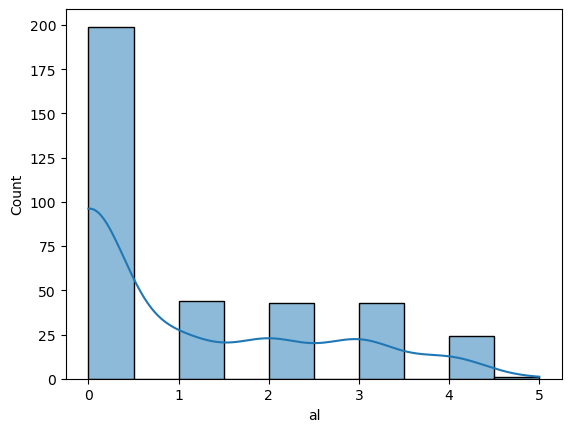

In [30]:
sns.histplot(df['al'] , kde=True)

In [31]:
df['al'].skew()

0.9981572420526745

In [32]:
df['al'] = df['al'].fillna(df['al'].median())


In [33]:
df['al'].isnull().sum()
df['al'].dtype

dtype('float64')

In [34]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [35]:
df['su'].value_counts()

su
0.0    290
2.0     18
3.0     14
4.0     13
1.0     13
5.0      3
Name: count, dtype: int64

<Axes: xlabel='su'>

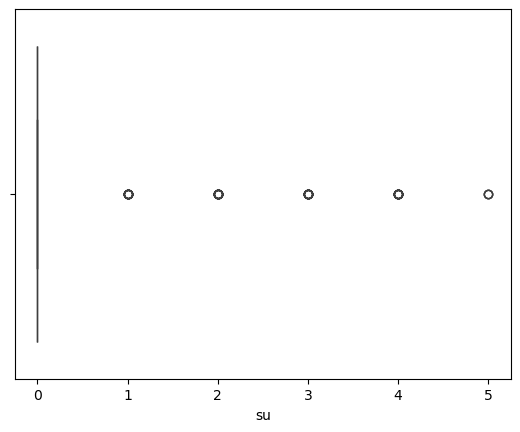

In [36]:
sns.boxplot(x=df['su'])


<Axes: xlabel='su', ylabel='Count'>

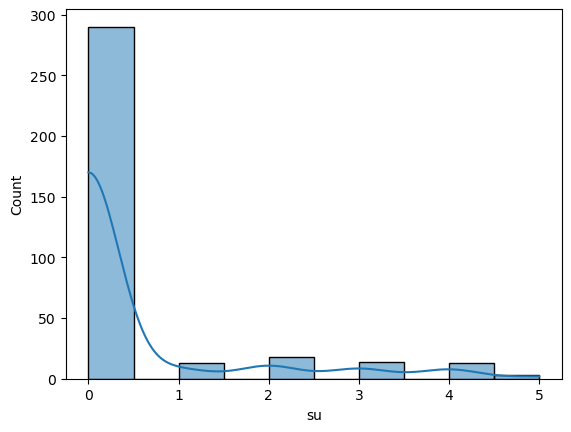

In [37]:
sns.histplot(df['su'] , kde=True)

In [38]:
df['su'] = df['su'].fillna(df['su'].median())


In [39]:
df['su'].isnull().sum()
df['su'].dtype

dtype('float64')

In [40]:
df['rbc'].value_counts()

rbc
normal      201
abnormal     47
Name: count, dtype: int64

In [41]:
df['rbc'] = df['rbc'].str.strip()


In [42]:
df['rbc'] = df['rbc'].map({'normal': 0, 'abnormal': 1})
#Binary encoding

<Axes: xlabel='rbc'>

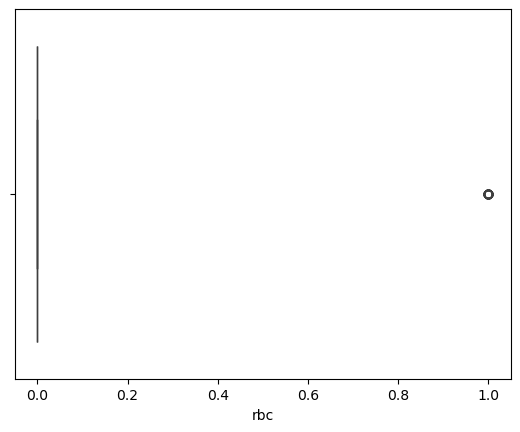

In [43]:
sns.boxplot(x=df['rbc'])

<Axes: xlabel='rbc', ylabel='Count'>

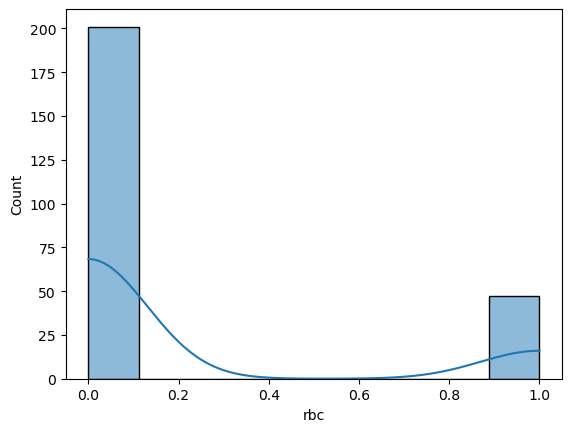

In [44]:
sns.histplot(df['rbc'] , kde=True)

In [45]:
df['rbc'].skew()

1.594090498133382

In [46]:
df['rbc']=df['rbc'].fillna(df.groupby('classification')['rbc'].transform(lambda x: x.mode()[0]))

In [47]:
df['rbc'].unique()

array([0., 1.])

In [48]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [49]:
df['pc'].unique()

array(['normal', 'abnormal', nan], dtype=object)

<Axes: xlabel='pc'>

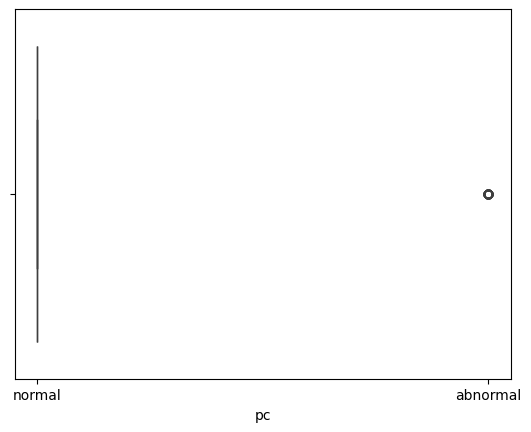

In [50]:
sns.boxplot(x=df['pc'])


<Axes: xlabel='pc', ylabel='Count'>

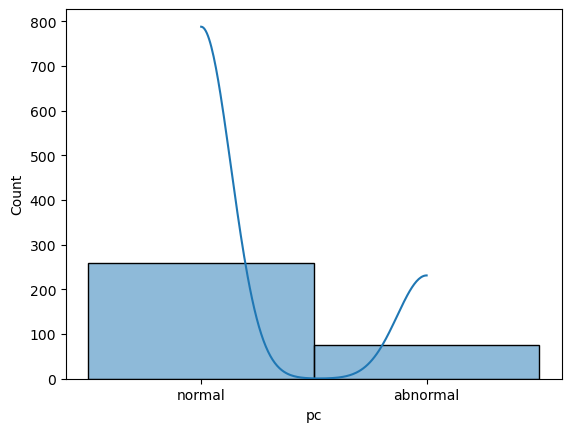

In [53]:
sns.histplot(df['pc'] , kde=True)

In [58]:
#First encode it 
df['pc']=df['pc'].str.strip()

In [59]:
df['pc']=df['pc'].map({'normal':0 , 'abnormal':1})

<Axes: xlabel='pc'>

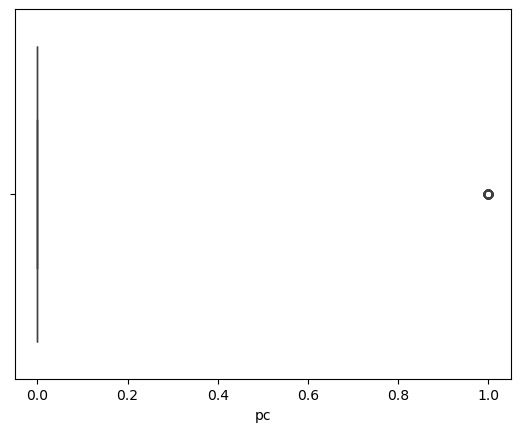

In [61]:
sns.boxplot(x=df['pc'])

<Axes: xlabel='pc', ylabel='Count'>

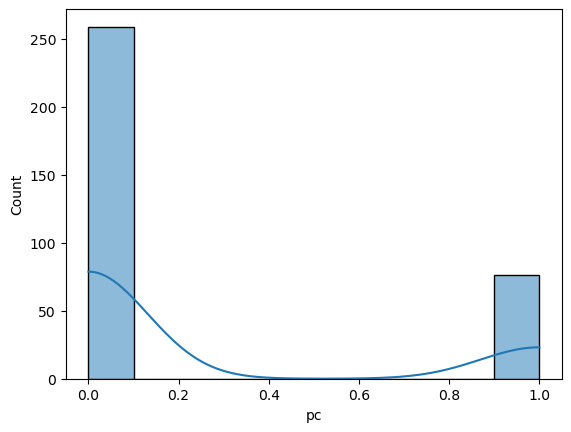

In [63]:
sns.histplot(df['pc'] , kde=True)

In [67]:
df['pc'].skew()

1.3102247983288748

In [69]:
df['pc']=df['pc'].fillna(df.groupby('classification')['pc'].transform('median'))

In [70]:
df['pc'].unique()

array([0., 1.])

In [71]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [72]:
#since pcc ba has few value we wil go with ffill

In [73]:
df['pcc']=df['pcc'].str.strip()

In [74]:
df['pcc']=df['pcc'].map({'present':0 , 'notpresent':1})

<Axes: xlabel='pcc'>

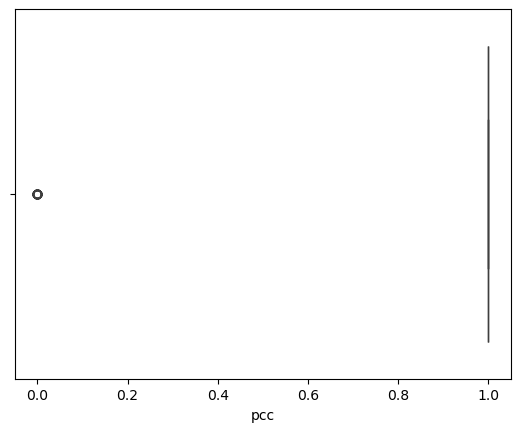

In [75]:
sns.boxplot(x=df['pcc'])

<Axes: xlabel='pcc', ylabel='Count'>

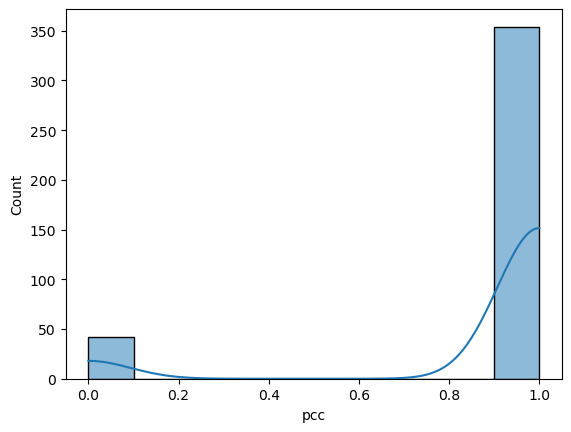

In [76]:
sns.histplot(df['pcc'] , kde=True)

In [77]:
df['pcc'].skew()

-2.5684921146030444

In [78]:
df['pcc']=df['pcc'].fillna(df.groupby('classification')['pc'].transform('median'))

In [79]:
df['pcc'].isnull().sum()


0

In [80]:
df['pcc'].tail(222)

178    0.0
179    0.0
180    0.0
181    0.0
182    1.0
      ... 
395    1.0
396    1.0
397    1.0
398    1.0
399    1.0
Name: pcc, Length: 222, dtype: float64

In [81]:
df['pc'].unique()

array([0., 1.])

In [82]:
df.isnull().sum()


id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 0
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [83]:
df['ba']=df['ba'].str.strip()

In [84]:
df['ba']=df['ba'].fillna(method='ffill')

In [85]:
df['ba'].isnull().sum()

0

In [87]:
df['ba']=df['ba'].map({'present':0 , 'notpresent':1})

In [88]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

<Axes: xlabel='bgr'>

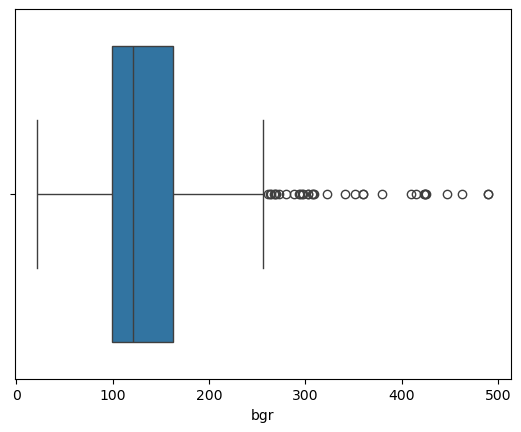

In [90]:
sns.boxplot(x=df['bgr'])

<Axes: xlabel='bgr', ylabel='Count'>

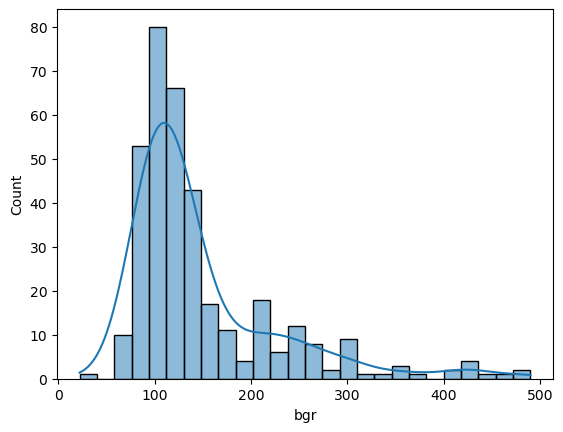

In [91]:
sns.histplot(df['bgr'] , kde=True)

In [92]:
df['bgr'].skew()

2.010773172514955

In [93]:
df['bgr']=df['bgr'].fillna(df['bgr'].mode()[0])

In [94]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

<Axes: xlabel='bu', ylabel='Count'>

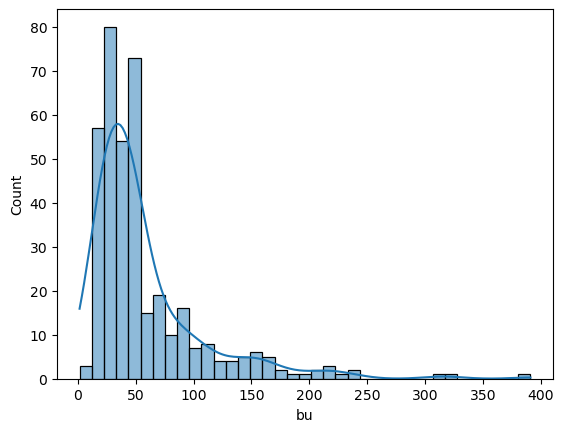

In [95]:
sns.histplot(df['bu'] ,kde=True)

In [96]:
df['bu'].skew()

2.6343744585903863

In [97]:
df['bu']=df['bu'].fillna(df['bu'].median())

<Axes: xlabel='sc', ylabel='Count'>

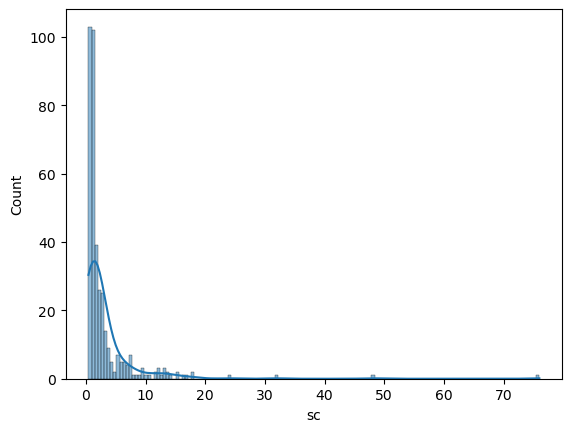

In [99]:
sns.histplot(df['sc'] , kde=True)

In [100]:
df['sc'].skew()

7.509538252140634

In [101]:
df['sc']=df['sc'].fillna(df['sc'].median())

In [102]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                  0
sc                  0
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

<Axes: xlabel='sod', ylabel='Count'>

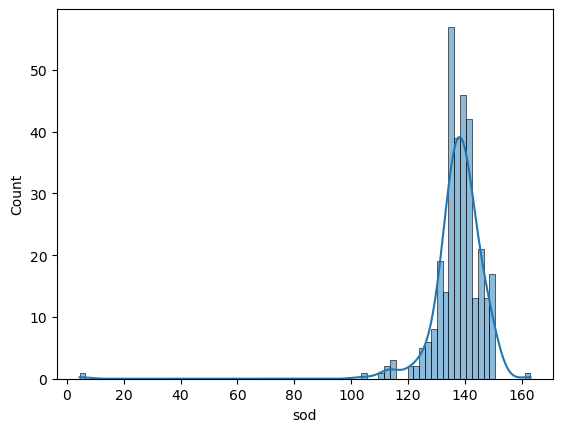

In [103]:
sns.histplot(df['sod'] , kde=True)

<Axes: xlabel='sod'>

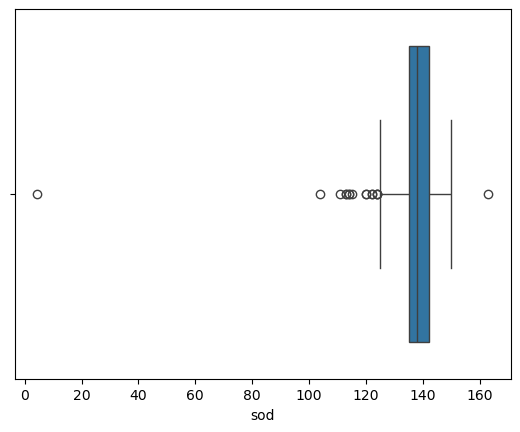

In [104]:
sns.boxplot(x=df['sod'])

In [105]:
df['sod'].skew()

-6.996568560937047

In [106]:
df['sod']=df['sod'].fillna(df['sod'].median())

<Axes: xlabel='pot'>

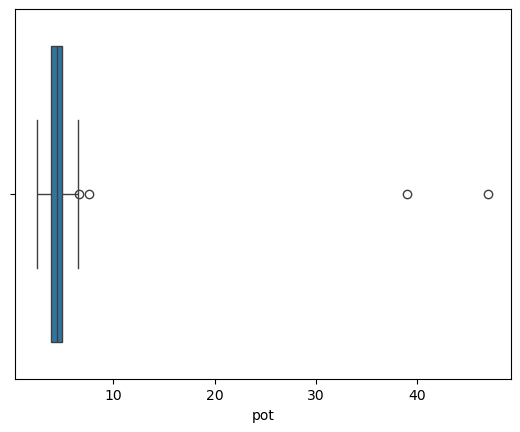

In [107]:
sns.boxplot(x=df['pot'])

In [108]:
df['pot'].value_counts()

pot
3.5     30
5.0     30
4.9     27
4.7     17
4.8     16
3.9     14
3.8     14
4.1     14
4.2     14
4.0     14
4.4     14
4.5     13
4.3     12
3.7     12
3.6      8
4.6      7
3.4      5
5.2      5
5.3      4
5.7      4
3.2      3
5.5      3
6.3      3
5.4      3
2.9      3
3.3      3
5.6      2
3.0      2
6.5      2
2.5      2
5.9      2
5.8      2
7.6      1
47.0     1
6.6      1
5.1      1
6.4      1
2.8      1
2.7      1
39.0     1
Name: count, dtype: int64

<Axes: xlabel='pot', ylabel='Count'>

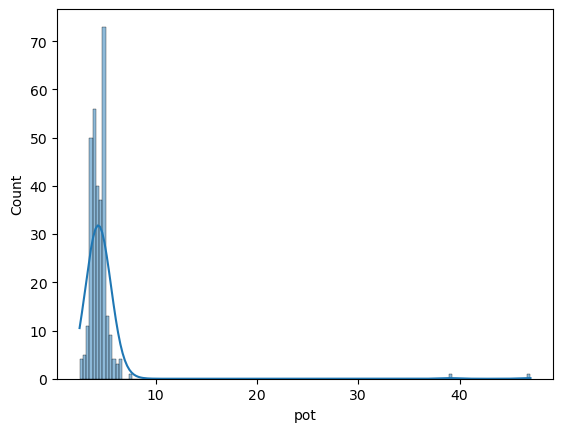

In [109]:
sns.histplot(df['pot'] , kde=True)

In [111]:
df['pot'].skew()

11.582955561754394

In [112]:
df['pot'] = df['pot'].fillna(df['pot'].median())


In [114]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

<Axes: xlabel='hemo', ylabel='Count'>

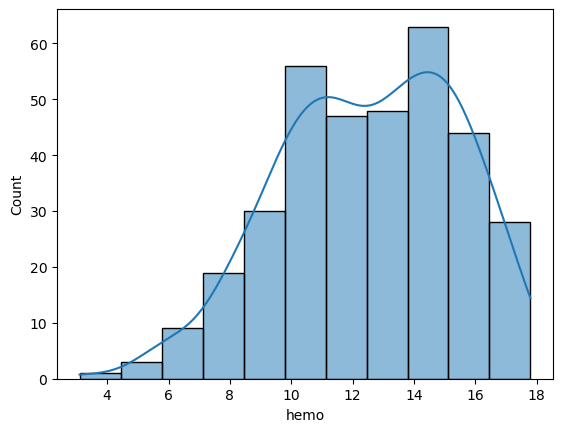

In [115]:
sns.histplot(df['hemo'] , kde=True)

<Axes: xlabel='hemo'>

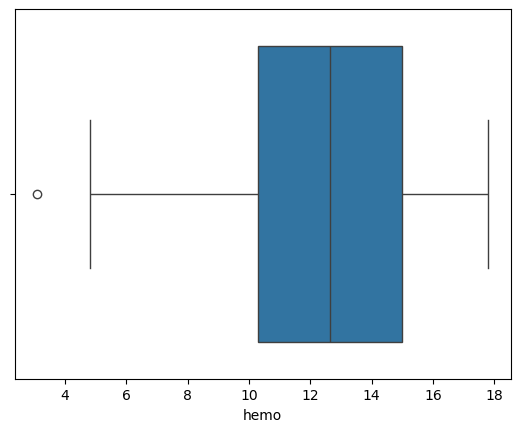

In [116]:
sns.boxplot(x=df['hemo'])

In [117]:
df['hemo'].skew()

-0.3350946791593011

In [118]:
df['hemo'].unique()

array([15.4, 11.3,  9.6, 11.2, 11.6, 12.2, 12.4, 10.8,  9.5,  9.4,  9.7,
        9.8,  5.6,  7.6, 12.6, 12.1, 12.7, 10.3,  7.7, 10.9,  nan, 11.1,
        9.9, 12.5, 12.9, 10.1, 12. , 13. ,  7.9,  9.3, 15. , 10. ,  8.6,
       13.6, 10.2, 10.5,  6.6, 11. ,  7.5, 15.6, 15.2,  4.8,  9.1,  8.1,
       11.9, 13.5,  8.3,  7.1, 16.1, 10.4,  9.2,  6.2, 13.9, 14.1,  6. ,
       11.8, 11.7, 11.4, 14. ,  8.2, 13.2,  6.1,  8. , 12.3,  8.4, 14.3,
        9. ,  8.7, 10.6, 13.1, 10.7,  5.5,  5.8,  6.8,  8.8,  8.5, 13.8,
       11.5,  7.3, 13.7, 12.8, 13.4,  6.3,  3.1, 17. , 15.9, 14.5, 15.5,
       16.2, 14.4, 14.2, 16.3, 14.8, 16.5, 15.7, 13.3, 14.6, 16.4, 16.9,
       16. , 14.7, 16.6, 14.9, 16.7, 16.8, 15.8, 15.1, 17.1, 17.2, 15.3,
       17.3, 17.4, 17.7, 17.8, 17.5, 17.6])

In [119]:
df['hemo']=df['hemo'].fillna(df['hemo'].mean())

In [120]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [122]:
df['pcv'].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '\t?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '41', '26',
       '15', '21', '43', '20', '\t43', '47', '9', '49', '50', '53', '51',
       '54'], dtype=object)

In [123]:
df['pcv'].isnull().sum()

70

<Axes: xlabel='pcv'>

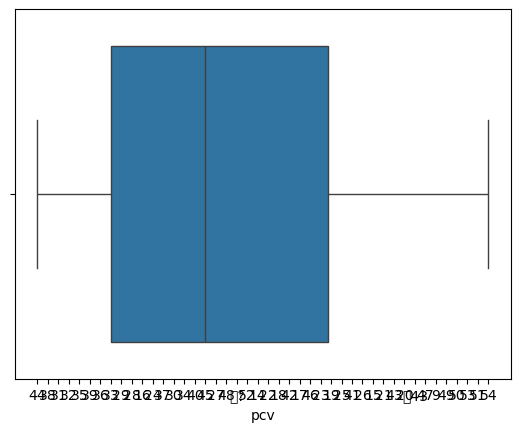

In [124]:
sns.boxplot(x=df['pcv'])

<Axes: xlabel='pcv', ylabel='Count'>

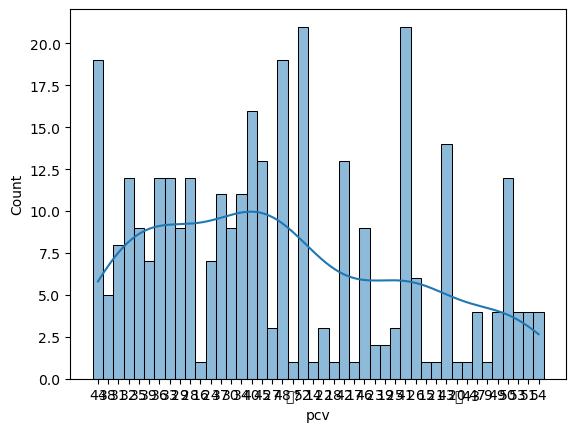

In [125]:
sns.histplot(df['pcv'] , kde=True)

In [211]:
df['pcv'].dtype

dtype('O')

In [213]:
df['pcv'] = df['pcv'].str.strip() 

In [215]:
print(df['pcv'].value_counts())


pcv
41    21
52    21
44    19
48    19
40    16
43    15
42    13
45    13
32    12
36    12
33    12
50    12
28    12
34    11
37    11
30     9
29     9
35     9
46     9
31     8
24     7
39     7
26     6
38     5
53     4
51     4
49     4
47     4
54     4
25     3
22     3
27     3
19     2
23     2
15     1
21     1
17     1
20     1
18     1
9      1
?      1
16     1
14     1
Name: count, dtype: int64


In [216]:
df['pcv']=df['pcv'].replace('?' , np.nan)

In [217]:
df['pcv'].dtype

dtype('O')

In [218]:
df['pcv']=pd.to_numeric(df['pcv'] , errors='coerce')

In [219]:
df['pcv'].dtype

dtype('float64')

<Axes: xlabel='pcv'>

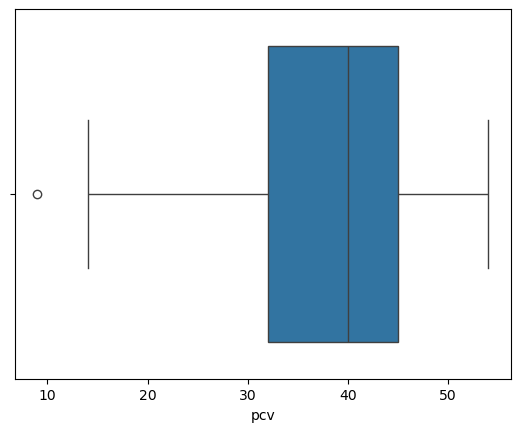

In [220]:
sns.boxplot(x=df['pcv'])

<Axes: xlabel='pcv', ylabel='Count'>

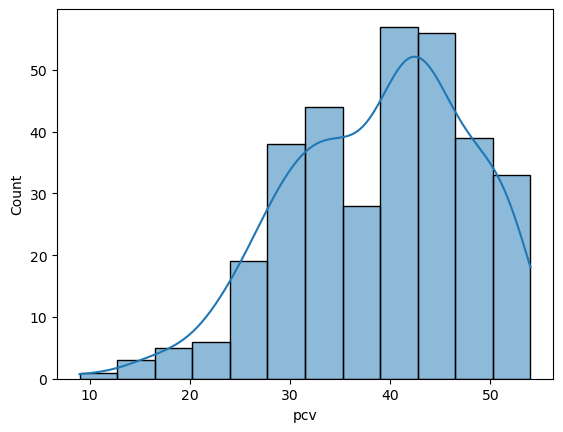

In [221]:
sns.histplot(df['pcv'] , kde=True)

In [222]:
df['pcv'].skew()

-0.4336785974434392

In [223]:
df['pcv'].value_counts()

pcv
41.0    21
52.0    21
44.0    19
48.0    19
40.0    16
43.0    15
42.0    13
45.0    13
32.0    12
50.0    12
36.0    12
33.0    12
28.0    12
34.0    11
37.0    11
30.0     9
29.0     9
35.0     9
46.0     9
31.0     8
24.0     7
39.0     7
26.0     6
38.0     5
53.0     4
51.0     4
49.0     4
47.0     4
54.0     4
25.0     3
27.0     3
22.0     3
19.0     2
23.0     2
15.0     1
21.0     1
20.0     1
17.0     1
9.0      1
18.0     1
14.0     1
16.0     1
Name: count, dtype: int64

In [224]:
df['pcv']=df['pcv'].fillna(df['pcv'].mean())

In [225]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                 0
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [226]:
df['wc'].unique()

array(['7800', '6000', '7500', '6700', '7300', nan, '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9800', '9100', '7900', '6400',
       '8600', '18900', '21600', '4300', '8500', '11300', '7200', '7700',
       '14600', '6300', '\t6200', '7100', '11800', '9400', '5500', '5800',
       '13200', '12500', '5600', '7000', '11900', '10400', '10700',
       '12700', '6800', '6500', '13600', '10200', '9000', '14900', '8200',
       '15200', '5000', '16300', '12400', '\t8400', '10500', '4200',
       '4700', '10900', '8100', '9500', '2200', '12800', '11200', '19100',
       '\t?', '12300', '16700', '2600', '26400', '8800', '7400', '4900',
       '8000', '12000', '15700', '4100', '5700', '11500', '5400', '10800',
       '9900', '5200', '5900', '9300', '9700', '5100', '6600'],
      dtype=object)

In [227]:
df['wc']=df['wc'].str.strip()

In [228]:
df['wc'].unique()

array(['7800', '6000', '7500', '6700', '7300', nan, '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9800', '9100', '7900', '6400',
       '8600', '18900', '21600', '4300', '8500', '11300', '7200', '7700',
       '14600', '6300', '7100', '11800', '9400', '5500', '5800', '13200',
       '12500', '5600', '7000', '11900', '10400', '10700', '12700',
       '6800', '6500', '13600', '10200', '9000', '14900', '8200', '15200',
       '5000', '16300', '12400', '10500', '4200', '4700', '10900', '8100',
       '9500', '2200', '12800', '11200', '19100', '?', '12300', '16700',
       '2600', '26400', '8800', '7400', '4900', '8000', '12000', '15700',
       '4100', '5700', '11500', '5400', '10800', '9900', '5200', '5900',
       '9300', '9700', '5100', '6600'], dtype=object)

In [231]:
df['wc']=df['wc'].replace('?' , np.nan)

In [232]:
df['wc'].unique()

array(['7800', '6000', '7500', '6700', '7300', nan, '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9800', '9100', '7900', '6400',
       '8600', '18900', '21600', '4300', '8500', '11300', '7200', '7700',
       '14600', '6300', '7100', '11800', '9400', '5500', '5800', '13200',
       '12500', '5600', '7000', '11900', '10400', '10700', '12700',
       '6800', '6500', '13600', '10200', '9000', '14900', '8200', '15200',
       '5000', '16300', '12400', '10500', '4200', '4700', '10900', '8100',
       '9500', '2200', '12800', '11200', '19100', '12300', '16700',
       '2600', '26400', '8800', '7400', '4900', '8000', '12000', '15700',
       '4100', '5700', '11500', '5400', '10800', '9900', '5200', '5900',
       '9300', '9700', '5100', '6600'], dtype=object)

<Axes: xlabel='wc', ylabel='Count'>

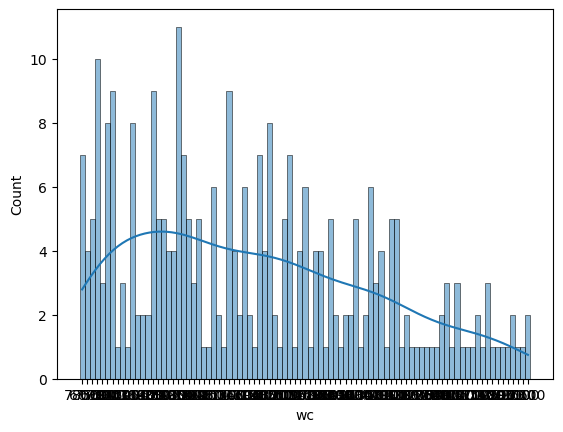

In [233]:
sns.histplot(df['wc'] , kde=True)

In [234]:
df['wc'].skew()

1.621589371911243

<Axes: xlabel='wc'>

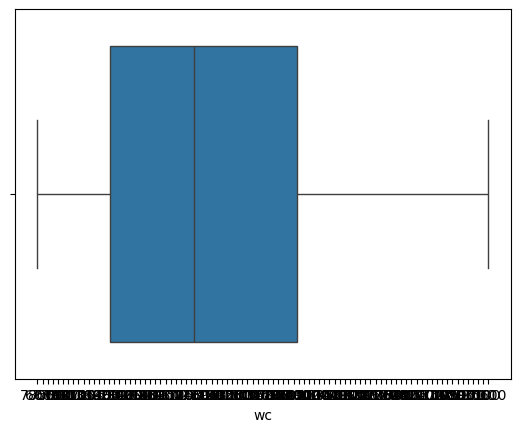

In [236]:
sns.boxplot(x=df['wc'])

In [237]:
df['wc'].dtype

dtype('O')

In [238]:
df['wc'] = pd.to_numeric(df['wc'], errors='coerce')


In [240]:
df['wc'].dtype

dtype('float64')

In [241]:
df['wc'] = df['wc'].fillna(df['wc'].median()) 


In [242]:
df['rc'].isnull().sum()

130

In [243]:
df['rc'].unique()

array(['5.2', nan, '3.9', '4.6', '4.4', '5', '4.0', '3.7', '3.8', '3.4',
       '2.6', '2.8', '4.3', '3.2', '3.6', '4', '4.1', '4.9', '2.5', '4.2',
       '4.5', '3.1', '4.7', '3.5', '6.0', '5.0', '2.1', '5.6', '2.3',
       '2.9', '2.7', '8.0', '3.3', '3.0', '3', '2.4', '4.8', '\t?', '5.4',
       '6.1', '6.2', '6.3', '5.1', '5.8', '5.5', '5.3', '6.4', '5.7',
       '5.9', '6.5'], dtype=object)

In [244]:
df['rc']=df['rc'].str.strip()

In [245]:
df['rc'].unique()

array(['5.2', nan, '3.9', '4.6', '4.4', '5', '4.0', '3.7', '3.8', '3.4',
       '2.6', '2.8', '4.3', '3.2', '3.6', '4', '4.1', '4.9', '2.5', '4.2',
       '4.5', '3.1', '4.7', '3.5', '6.0', '5.0', '2.1', '5.6', '2.3',
       '2.9', '2.7', '8.0', '3.3', '3.0', '3', '2.4', '4.8', '?', '5.4',
       '6.1', '6.2', '6.3', '5.1', '5.8', '5.5', '5.3', '6.4', '5.7',
       '5.9', '6.5'], dtype=object)

In [246]:
df['rc']=df['rc'].replace('?' , np.nan)

In [247]:
df['rc'].unique()

array(['5.2', nan, '3.9', '4.6', '4.4', '5', '4.0', '3.7', '3.8', '3.4',
       '2.6', '2.8', '4.3', '3.2', '3.6', '4', '4.1', '4.9', '2.5', '4.2',
       '4.5', '3.1', '4.7', '3.5', '6.0', '5.0', '2.1', '5.6', '2.3',
       '2.9', '2.7', '8.0', '3.3', '3.0', '3', '2.4', '4.8', '5.4', '6.1',
       '6.2', '6.3', '5.1', '5.8', '5.5', '5.3', '6.4', '5.7', '5.9',
       '6.5'], dtype=object)

In [248]:
df['rc']=pd.to_numeric(df['rc'] , errors='coerce')

In [249]:
df['rc'].dtype

dtype('float64')

<Axes: xlabel='rc'>

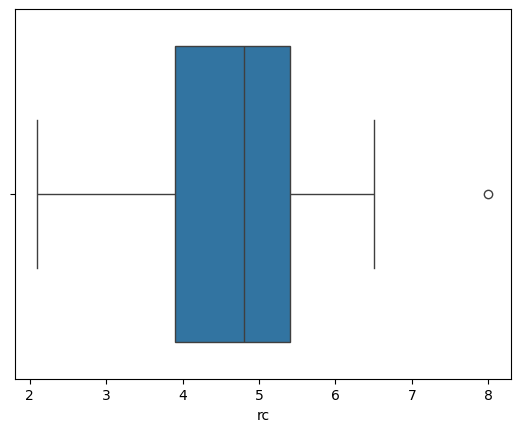

In [251]:
sns.boxplot(x=df['rc'])

<Axes: xlabel='rc', ylabel='Count'>

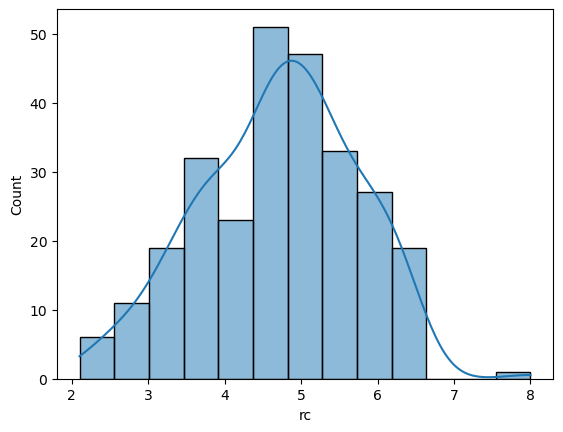

In [279]:
sns.histplot(df['rc'] , kde=True)

In [281]:
df['rc'].skew()

-0.1833293207517324

In [282]:
df['rc']=df['rc'].fillna(df['rc'].mean())

In [283]:
df.isnull().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               2
dm                2
cad               2
appet             1
pe                1
ane               1
classification    0
dtype: int64

In [284]:
df['htn'].value_counts()

htn
no     251
yes    147
Name: count, dtype: int64

In [285]:
df['htn']=df['htn'].map({'yes':0 , 'no':1})

In [286]:
df['htn'].value_counts()

htn
1.0    251
0.0    147
Name: count, dtype: int64

<Axes: xlabel='htn', ylabel='Count'>

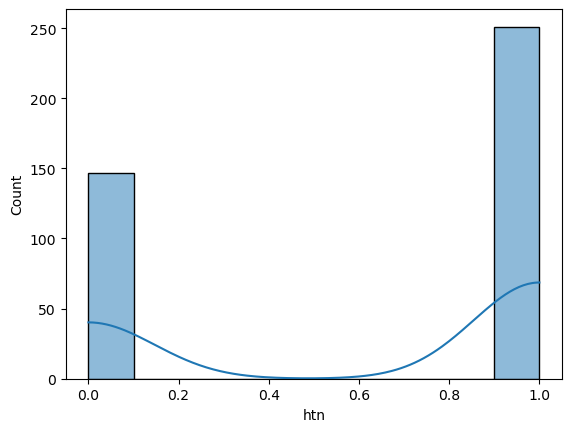

In [287]:
sns.histplot(df['htn'] , kde=True)

In [288]:
df['htn'].skew()

-0.5434748041079175

In [289]:
#since it is categorical we fill with group by 
df['htn']=df['htn'].fillna(df.groupby('classification')['htn'].transform(lambda x : x.mode().iloc[0]))

In [290]:
df['htn'].isnull().sum()

0

In [291]:
df['dm'].unique()

array(['yes', 'no', ' yes', '\tno', '\tyes', nan], dtype=object)

In [292]:
df['dm']=df['dm'].str.strip()

In [293]:
df['dm'].value_counts()

dm
no     261
yes    137
Name: count, dtype: int64

In [296]:
df['dm']=df['dm'].map({'yes':0 , 'no':1})

<Axes: xlabel='dm', ylabel='Count'>

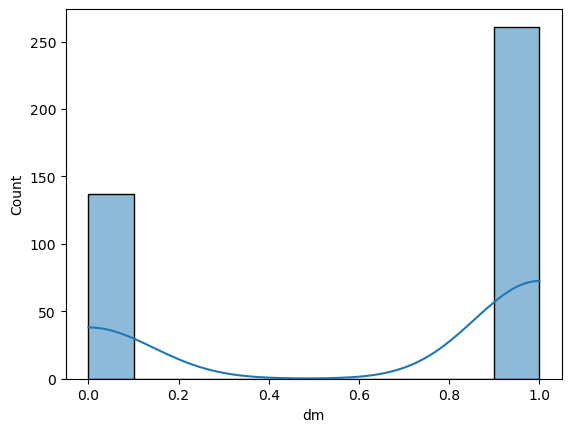

In [298]:
sns.histplot(df['dm'] , kde=True)

In [301]:
df['dm'].skew()

-0.6582376983220679

In [302]:
df['dm']=df['dm'].fillna(df.groupby('classification')['dm'].transform(lambda x : x.mode().iloc[0]))

In [303]:
df['dm'].isnull().sum()

0

In [304]:
df['cad'].unique()

array(['no', 'yes', '\tno', nan], dtype=object)

In [305]:
df['cad']=df['cad'].str.strip()

In [306]:
df['cad'].value_counts()

cad
no     364
yes     34
Name: count, dtype: int64

In [307]:
df['cad']=df['cad'].map({'yes':0 , 'no':1})

In [308]:
df['cad']=df['cad'].fillna(df.groupby('classification')['cad'].transform(lambda x : x.mode().iloc[0]))

In [309]:
df['cad'].dtype

dtype('float64')

In [310]:
df['appet'].value_counts()

appet
good    317
poor     82
Name: count, dtype: int64

In [311]:
df['appet']=df['appet'].fillna(df.groupby('classification')['appet'].transform(lambda x : x.mode().iloc[0]))

In [313]:
df['appet']=df['appet'].map({'good':0 , 'poor':1})

In [314]:
df['appet'].dtype

dtype('int64')

In [315]:
df['appet'].isnull().sum()

0

In [317]:
df['pe'].value_counts()

pe
no     323
yes     76
Name: count, dtype: int64

In [318]:
df['pe']=df['pe'].map({'yes':0 , 'no':1})

In [343]:
df['pe']=df['pe'].fillna(df.groupby('classification')['pe'].transform(lambda x : x.mode().iloc[0]))

In [345]:
df['pe'].dtype

dtype('float64')

In [346]:
df['ane'].value_counts()

ane
no     339
yes     60
Name: count, dtype: int64

In [347]:
df['ane']=df['ane'].map({'yes':0 , 'no':1})

In [348]:
df['ane']=df['ane'].fillna(df.groupby('classification')['ane'].transform(lambda x : x.mode().iloc[0]))

In [349]:
df['ane'].value_counts()

ane
1.0    340
0.0     60
Name: count, dtype: int64

In [352]:
df['classification'].unique()


array(['ckd', 'ckd\t', 'notckd'], dtype=object)

In [353]:
df['classification'].str.strip()


0         ckd
1         ckd
2         ckd
3         ckd
4         ckd
        ...  
395    notckd
396    notckd
397    notckd
398    notckd
399    notckd
Name: classification, Length: 400, dtype: object

In [354]:
df['classification'] = df['classification'].str.strip().str.lower()


In [355]:
df['classification'].unique()

array(['ckd', 'notckd'], dtype=object)

In [356]:
df['classification'].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [357]:
df['classification']=df['classification'].map({'ckd':0 , 'notckd':1})

In [358]:
df.isnull().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [359]:
#Save as a new CSV file:
df.to_csv("cleaned_chronic_kidney_disease.csv", index=False)


In [360]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             400 non-null    float64
 2   bp              400 non-null    float64
 3   sg              400 non-null    float64
 4   al              400 non-null    float64
 5   su              400 non-null    float64
 6   rbc             400 non-null    float64
 7   pc              400 non-null    float64
 8   pcc             400 non-null    float64
 9   ba              400 non-null    int64  
 10  bgr             400 non-null    float64
 11  bu              400 non-null    float64
 12  sc              400 non-null    float64
 13  sod             400 non-null    float64
 14  pot             400 non-null    float64
 15  hemo            400 non-null    float64
 16  pcv             400 non-null    float64
 17  wc              400 non-null    flo

In [374]:
df = pd.read_csv("cleaned_chronic_kidney_disease.csv")


In [376]:
df.isnull().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

<Axes: ylabel='count'>

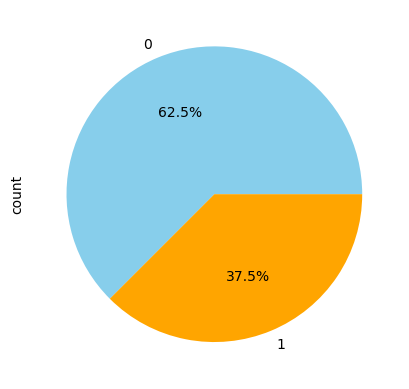

In [377]:
df['classification'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'orange'])


In [378]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             400 non-null    float64
 2   bp              400 non-null    float64
 3   sg              400 non-null    float64
 4   al              400 non-null    float64
 5   su              400 non-null    float64
 6   rbc             400 non-null    float64
 7   pc              400 non-null    float64
 8   pcc             400 non-null    float64
 9   ba              400 non-null    int64  
 10  bgr             400 non-null    float64
 11  bu              400 non-null    float64
 12  sc              400 non-null    float64
 13  sod             400 non-null    float64
 14  pot             400 non-null    float64
 15  hemo            400 non-null    float64
 16  pcv             400 non-null    float64
 17  wc              400 non-null    flo

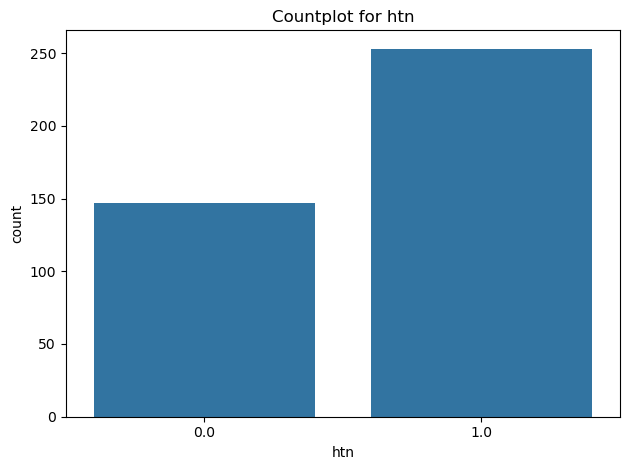

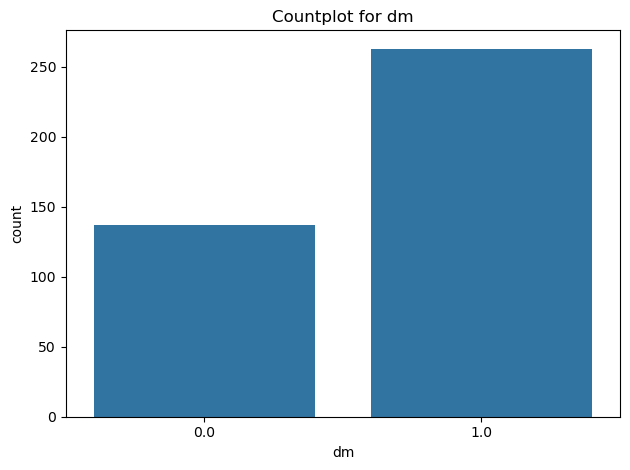

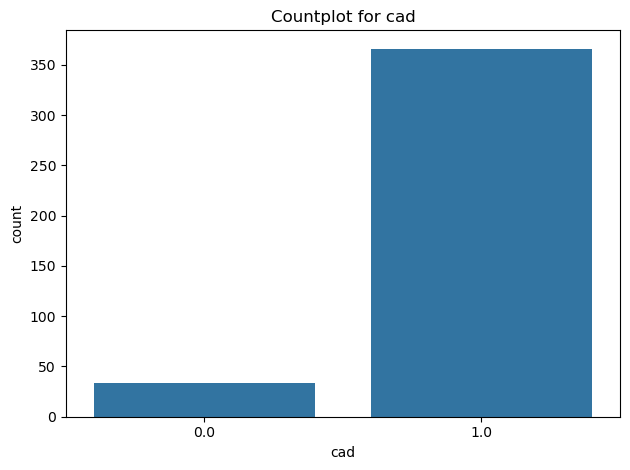

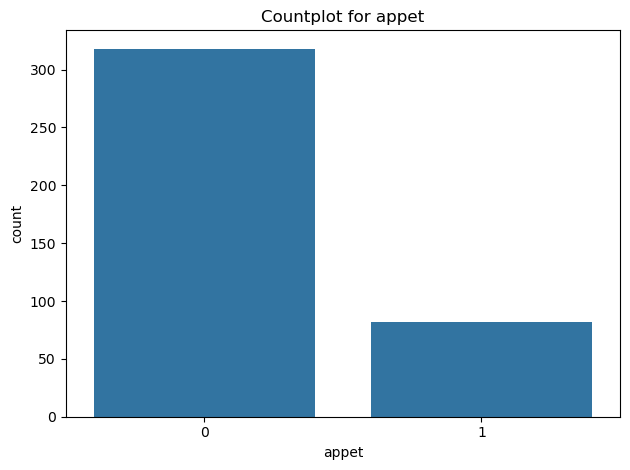

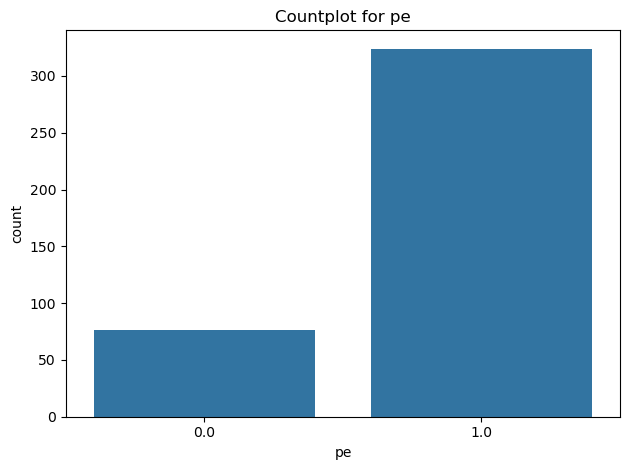

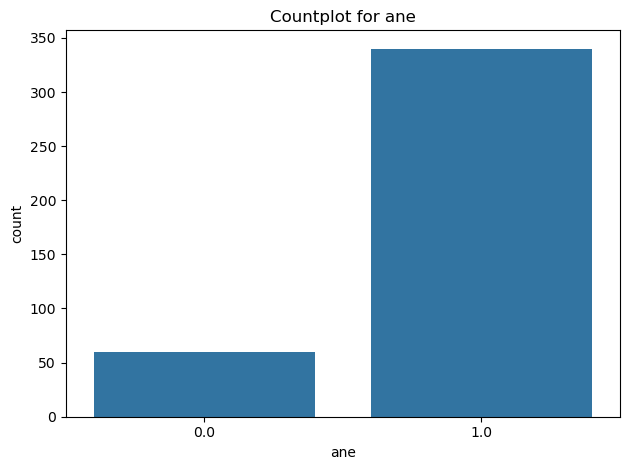

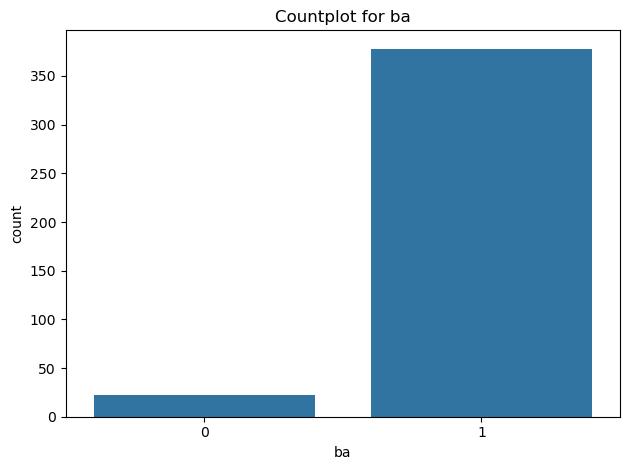

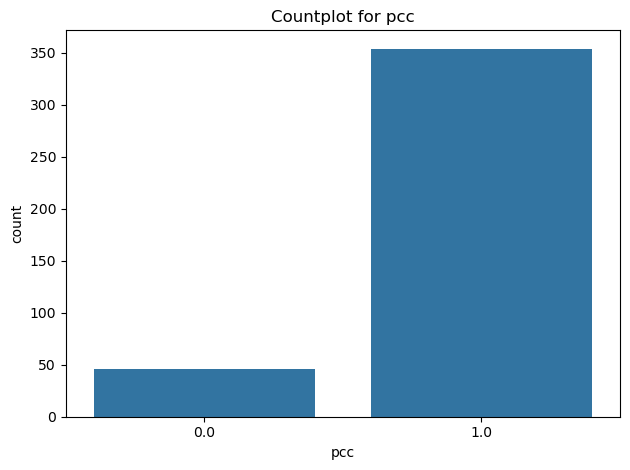

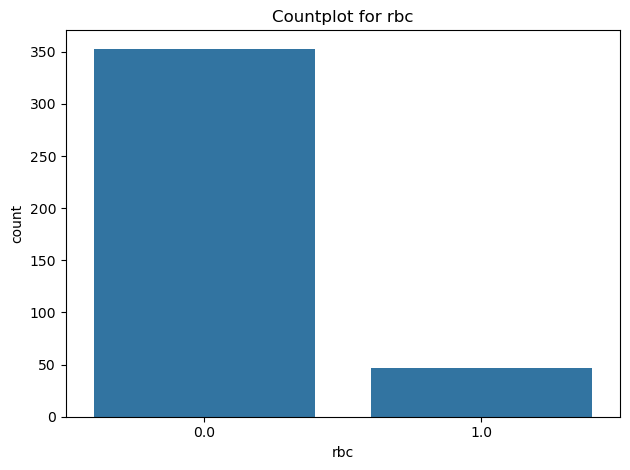

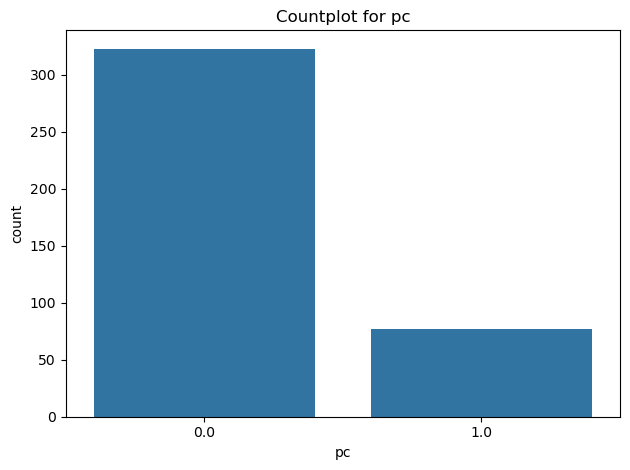

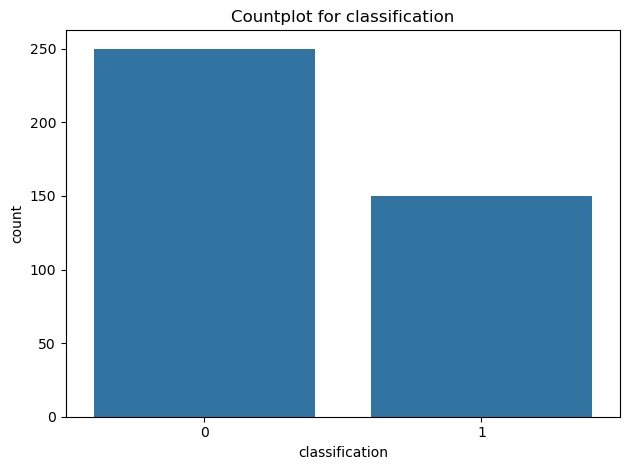

In [379]:
#univaraite analysis
categorical_cols = ['htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'ba', 'pcc', 'rbc', 'pc', 'classification']
for col in categorical_cols:
    sns.countplot(x=col, data=df)
    plt.title(f'Countplot for {col}')
    plt.tight_layout()
    plt.show()

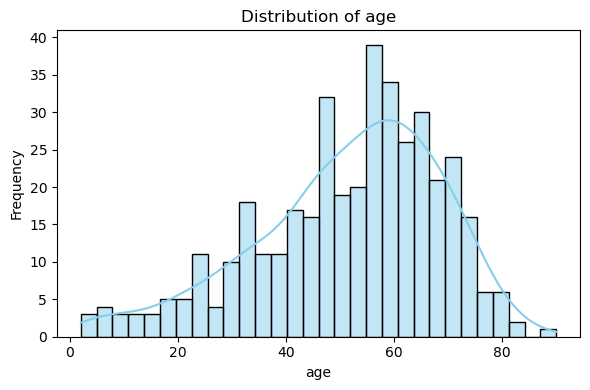

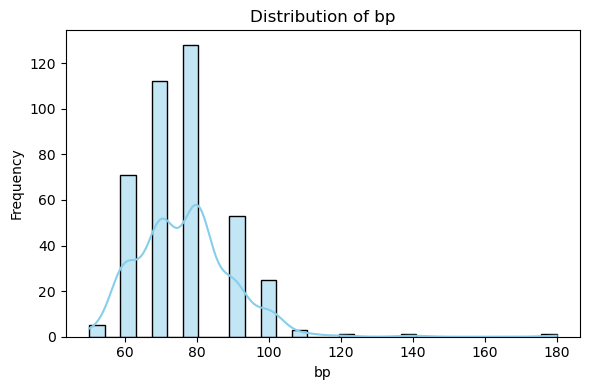

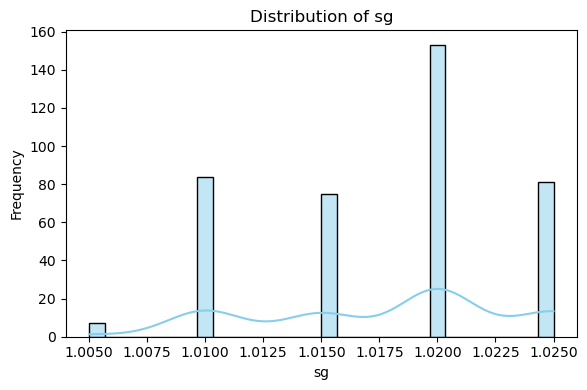

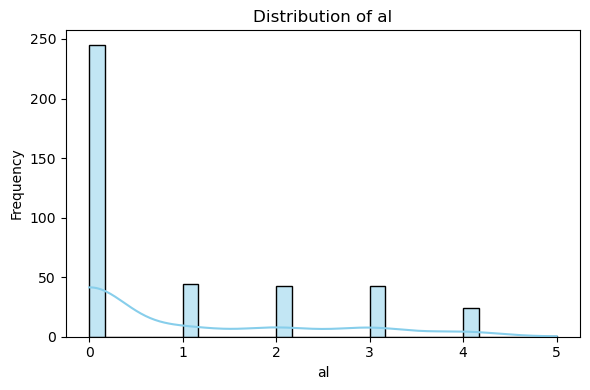

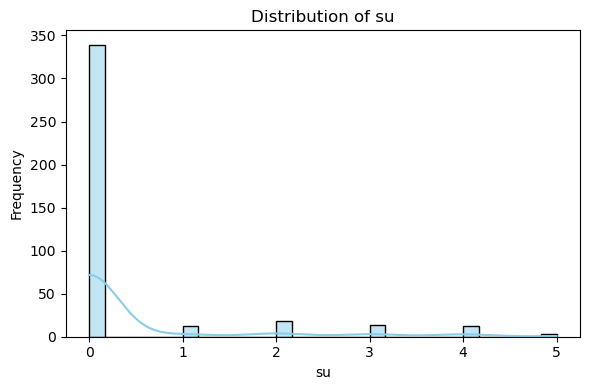

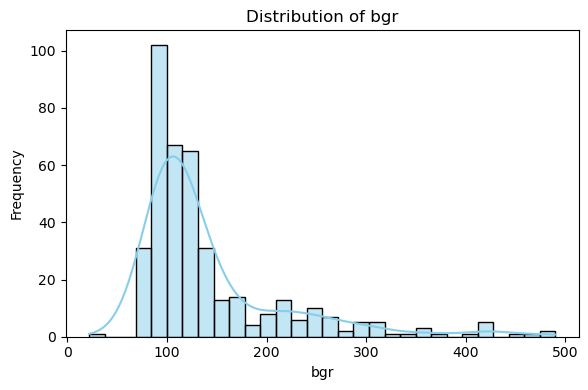

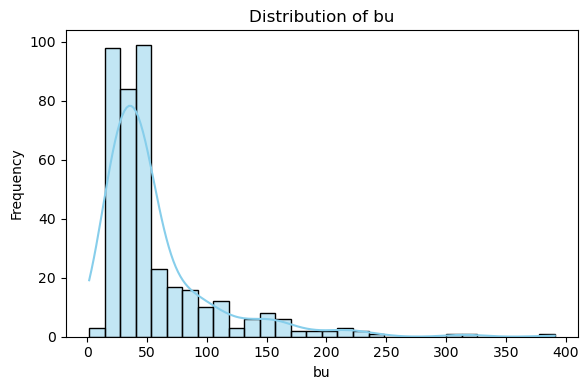

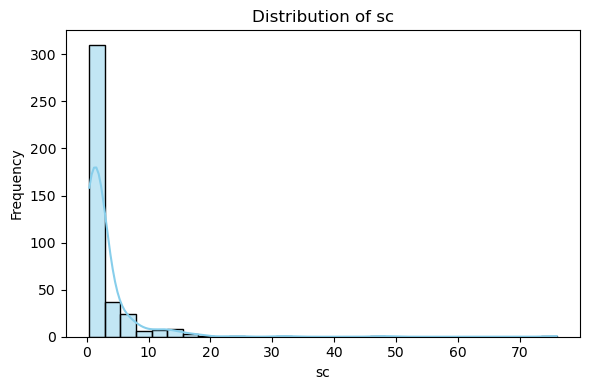

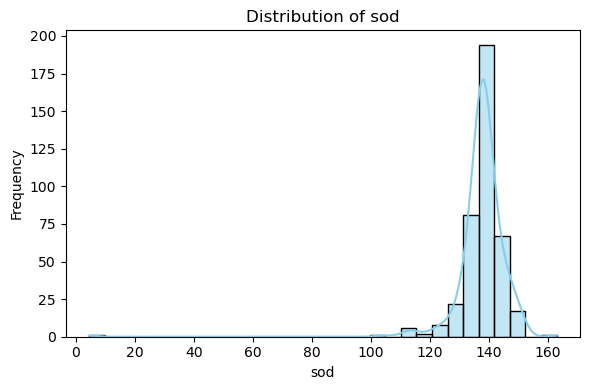

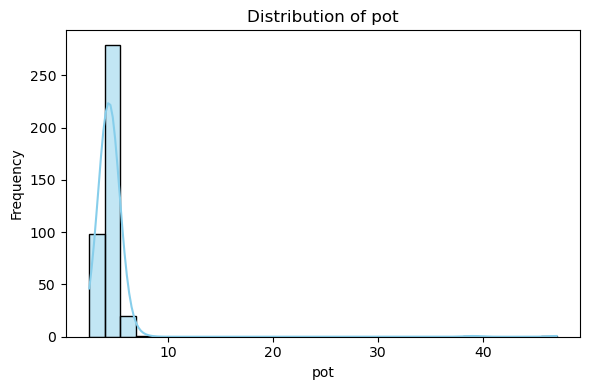

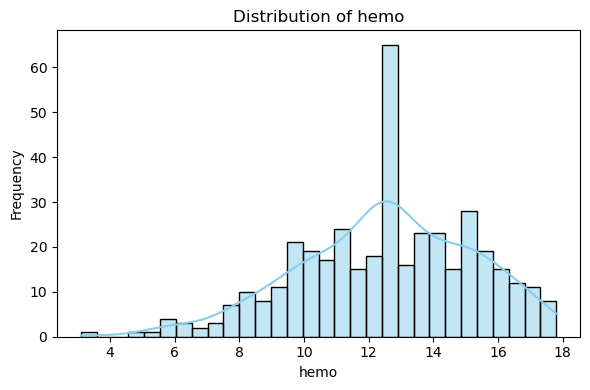

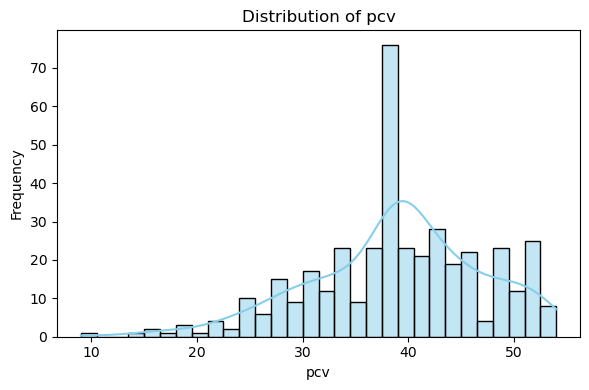

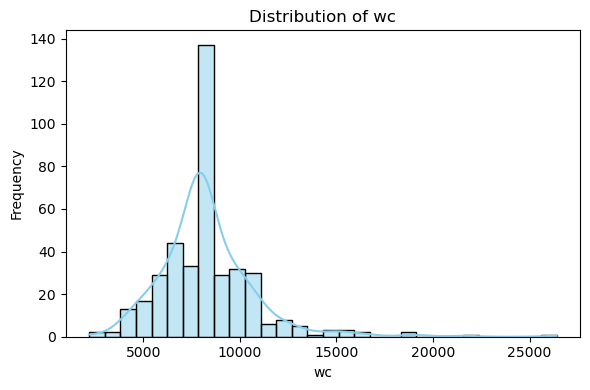

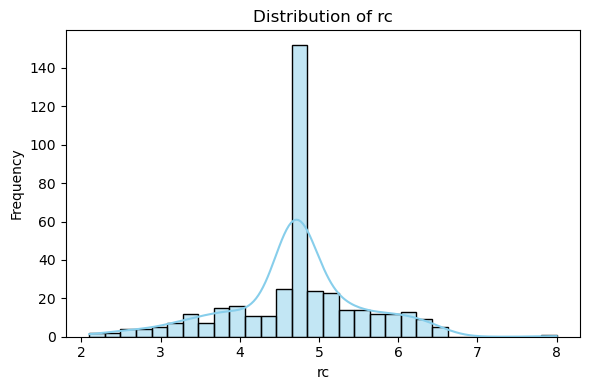

In [380]:
numerical_cols = [
    'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc',
    'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc'
]
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

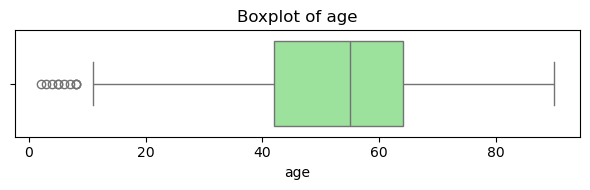

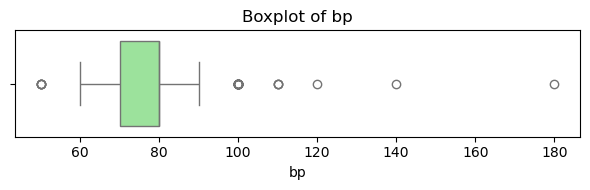

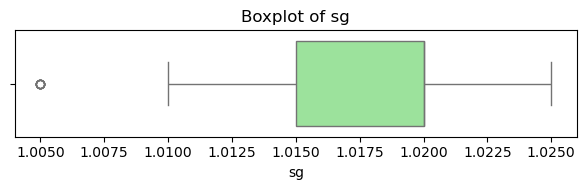

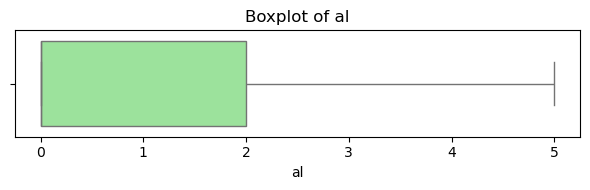

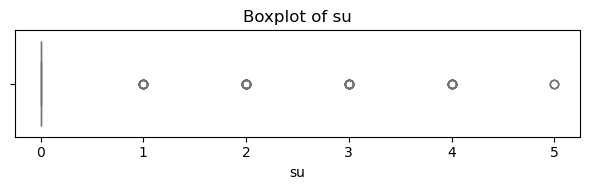

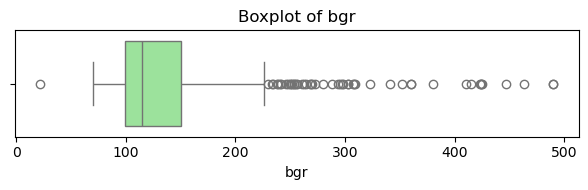

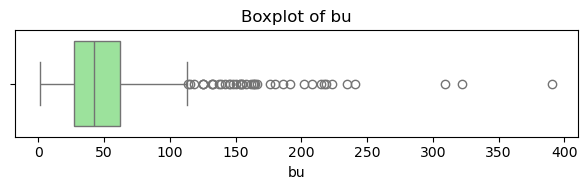

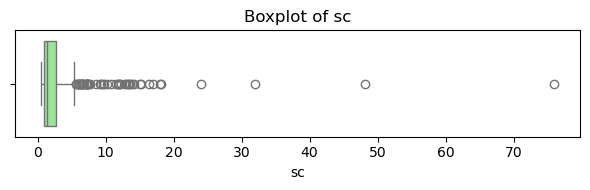

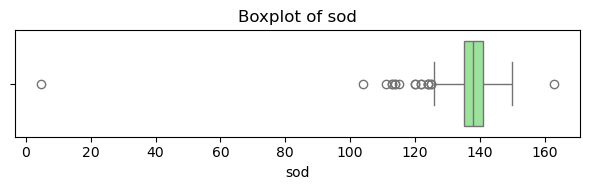

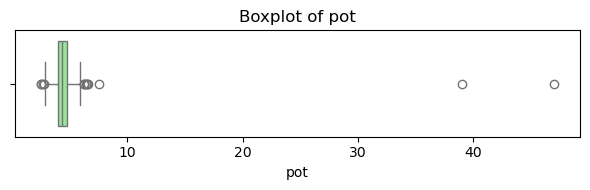

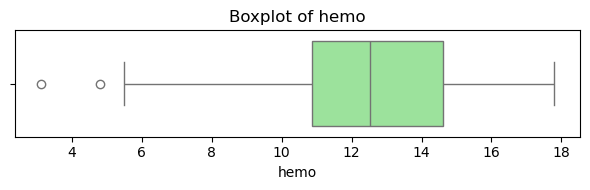

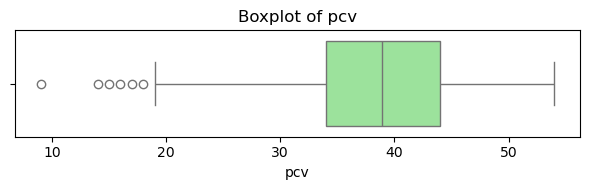

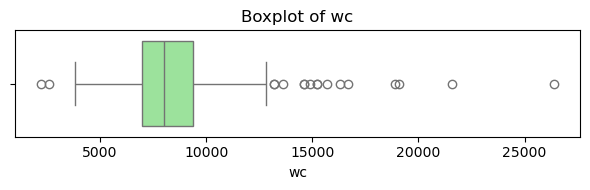

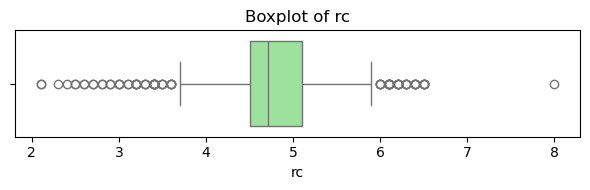

In [381]:
for col in numerical_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()


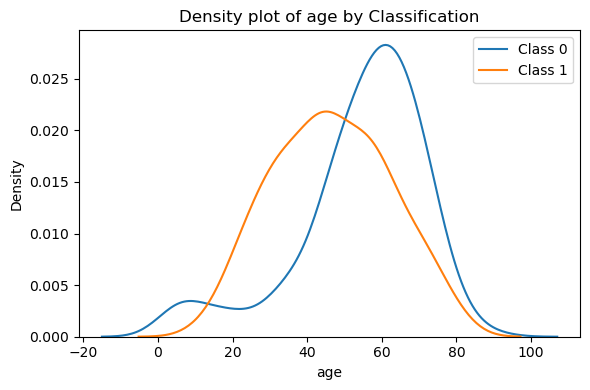

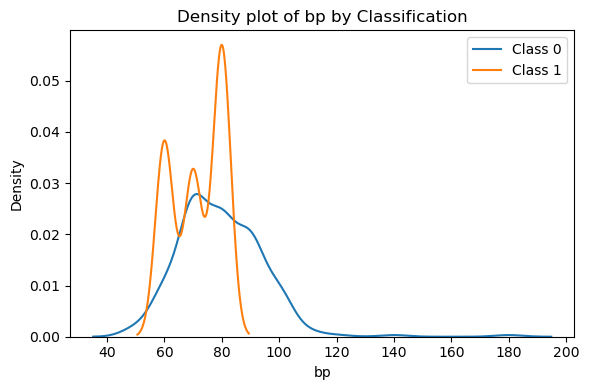

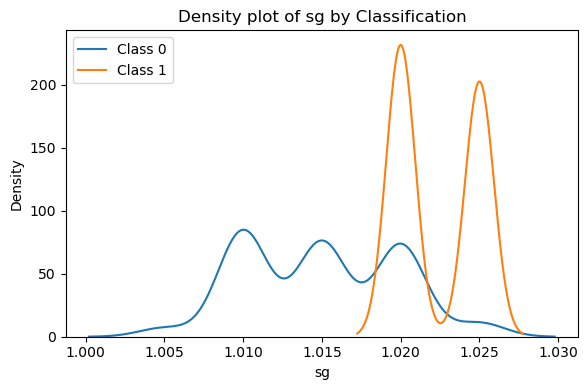

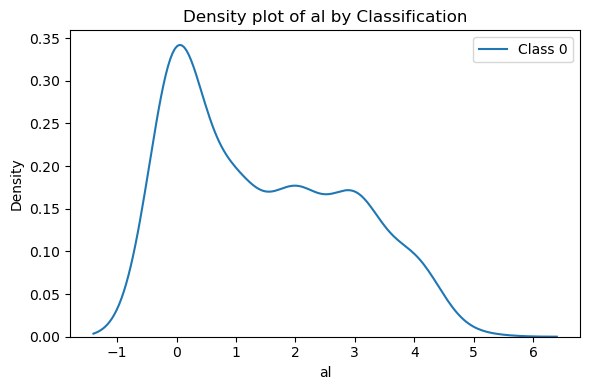

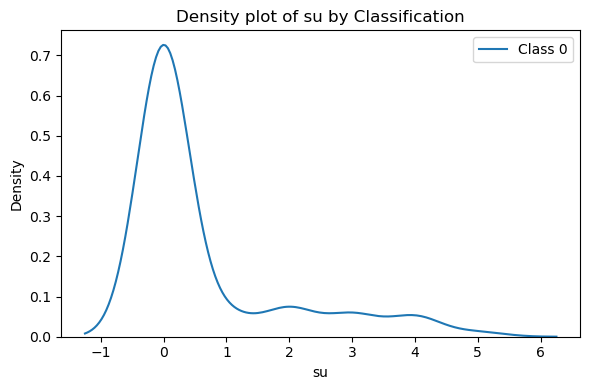

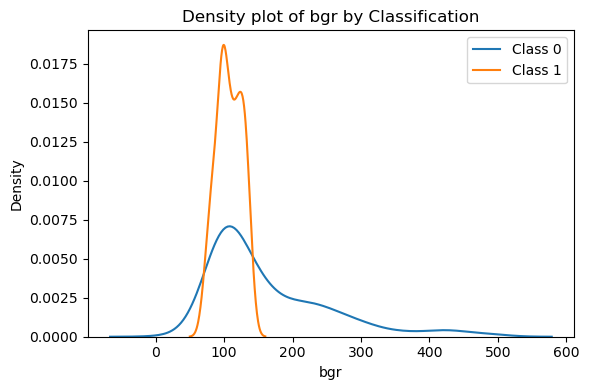

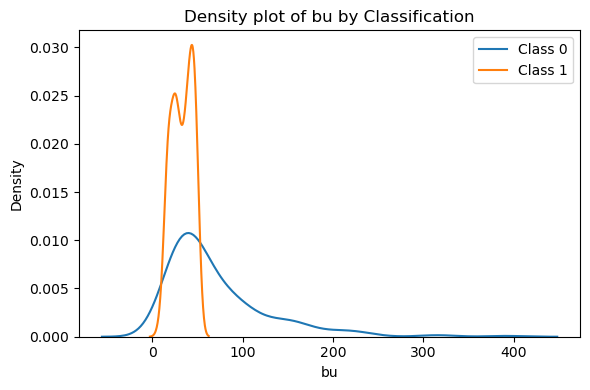

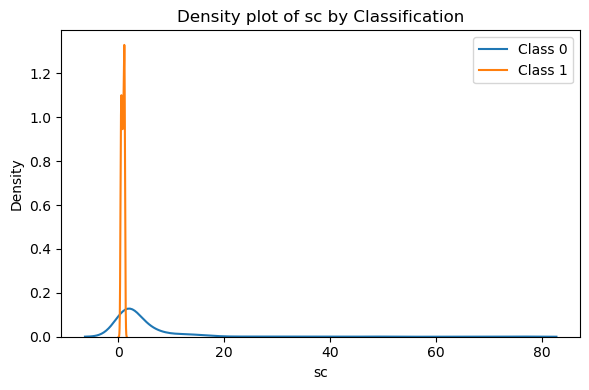

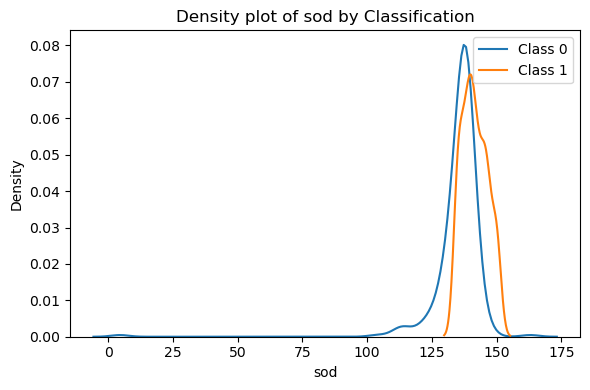

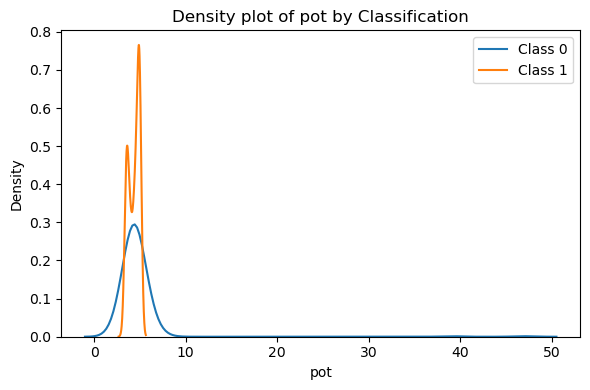

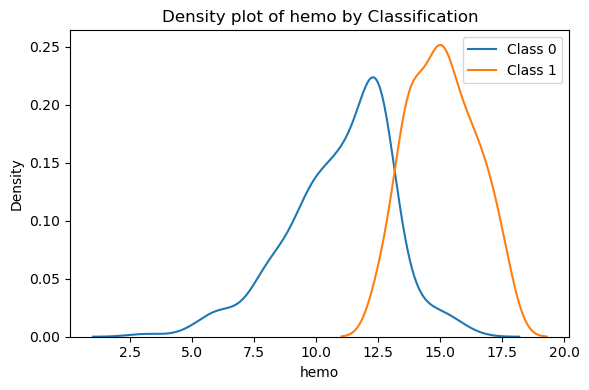

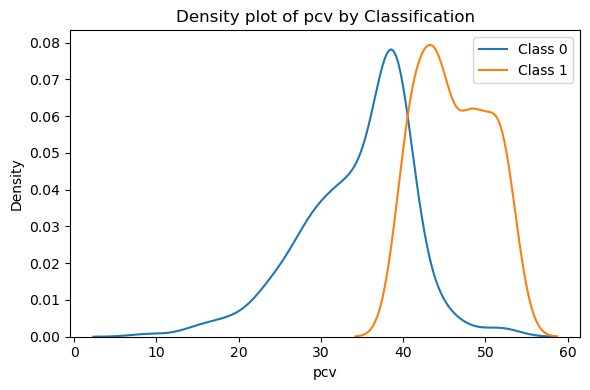

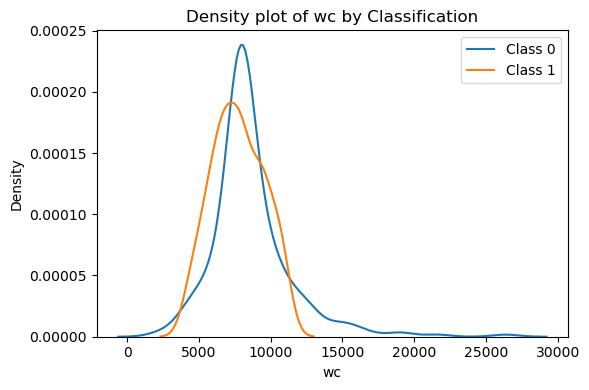

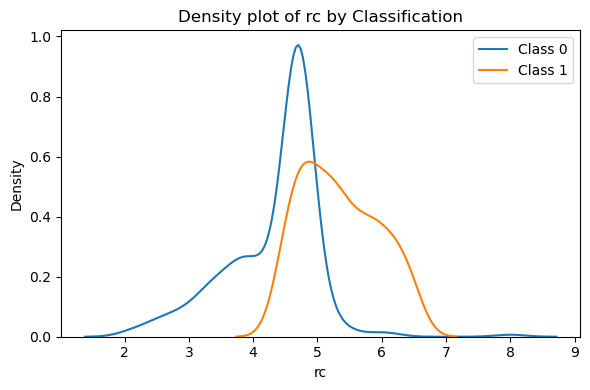

In [382]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    for cls in df['classification'].unique():
        subset = df[df['classification'] == cls]
        sns.kdeplot(subset[col], label=f'Class {cls}')
    plt.title(f'Density plot of {col} by Classification')
    plt.xlabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()


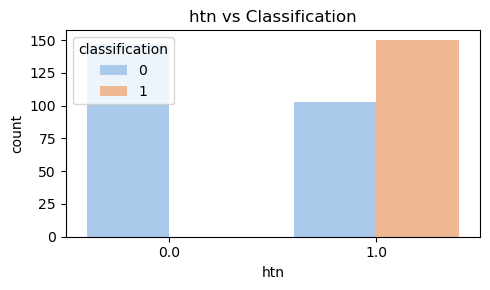

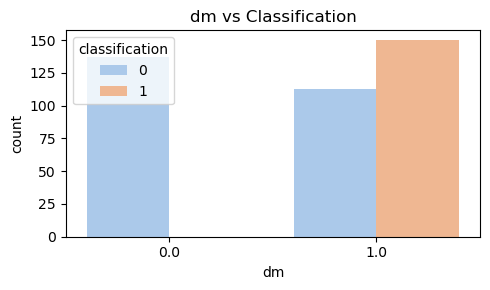

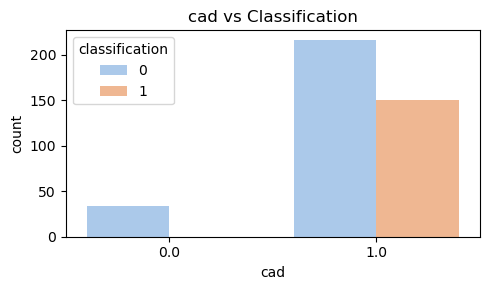

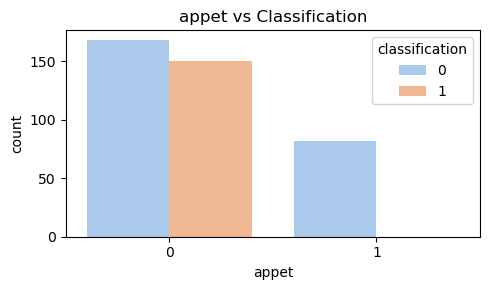

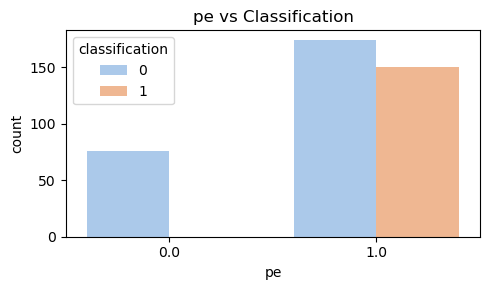

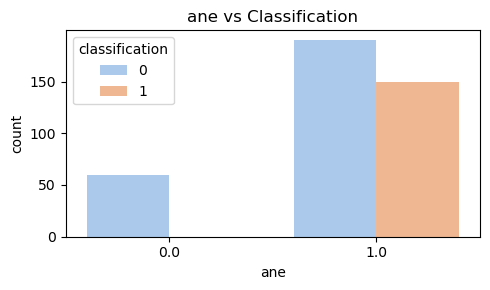

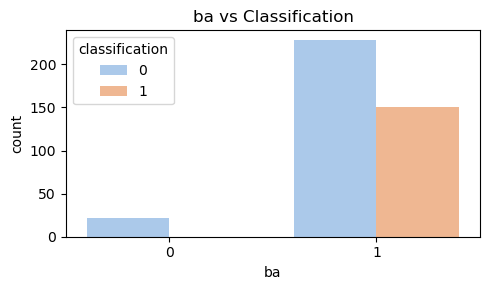

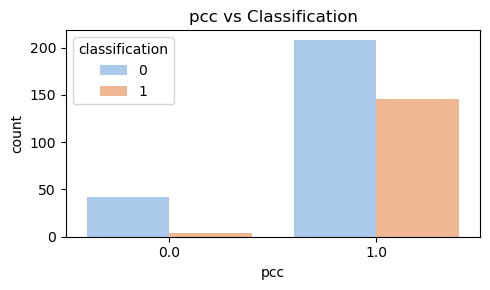

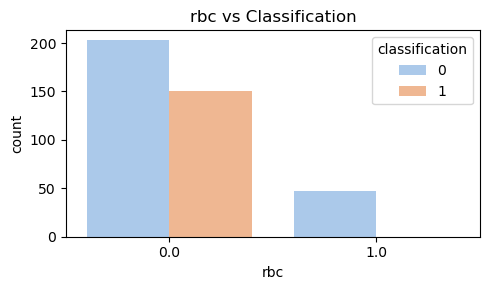

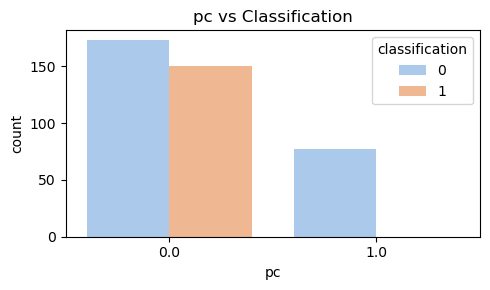

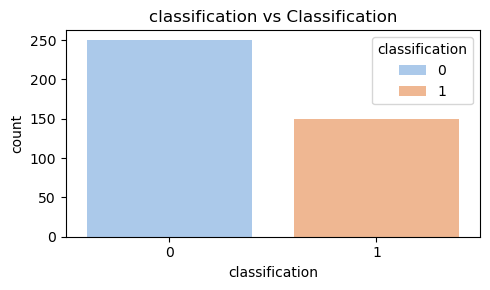

In [383]:
for col in categorical_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=col, hue='classification', palette='pastel')
    plt.title(f'{col} vs Classification')
    plt.tight_layout()
    plt.show()


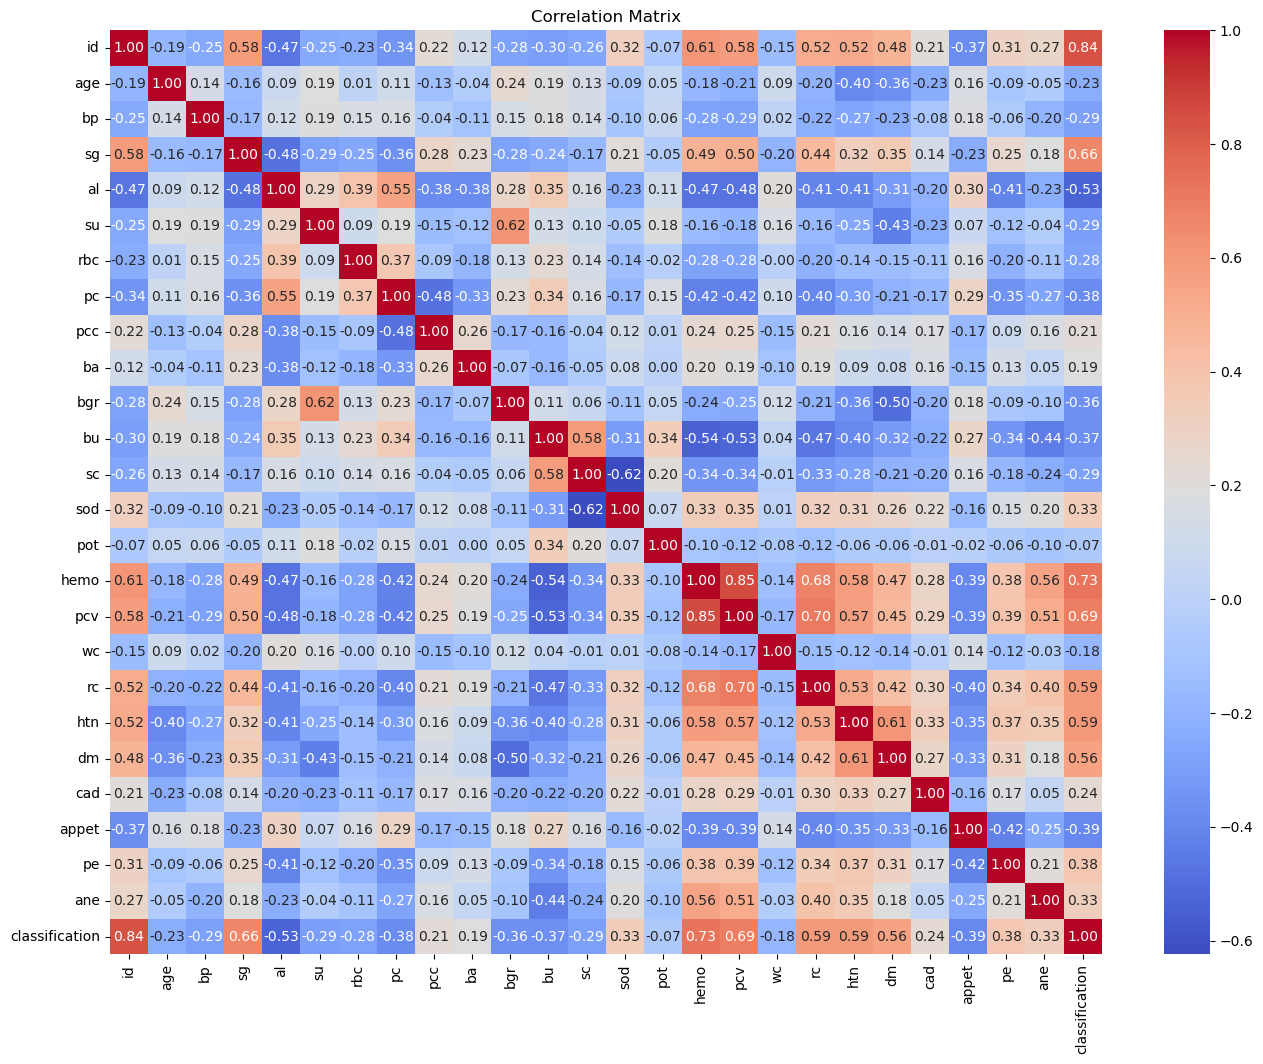

In [384]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [385]:
correlation_with_target = df.corr()['classification'].drop('classification')
correlation_with_target = correlation_with_target.abs().sort_values(ascending=False)

print(correlation_with_target)


id       0.838528
hemo     0.729628
pcv      0.690060
sg       0.659504
rc       0.590913
htn      0.590438
dm       0.559060
al       0.531562
appet    0.393341
pc       0.378198
pe       0.375154
bu       0.369393
bgr      0.358293
sod      0.334900
ane      0.325396
su       0.294555
bp       0.293693
sc       0.291245
rbc      0.282642
cad      0.236088
age      0.227842
pcc      0.214476
ba       0.186871
wc       0.177571
pot      0.065218
Name: classification, dtype: float64


In [386]:
#ID WITH CLASSIDFICATION HAS HIGH 0.83 CORRELATION 
#iD COLUMN WONT HAVE ANYTHING TO HELP IN PREDICTION SO WE DROP ID COLUMN
df.drop(columns=['id'], inplace=True)


In [387]:
correlation_with_target = df.corr()['classification'].drop('classification')
correlation_with_target = correlation_with_target.abs().sort_values(ascending=False)
print(correlation_with_target.head)  # Top 10 most relevant features


<bound method NDFrame.head of hemo     0.729628
pcv      0.690060
sg       0.659504
rc       0.590913
htn      0.590438
dm       0.559060
al       0.531562
appet    0.393341
pc       0.378198
pe       0.375154
bu       0.369393
bgr      0.358293
sod      0.334900
ane      0.325396
su       0.294555
bp       0.293693
sc       0.291245
rbc      0.282642
cad      0.236088
age      0.227842
pcc      0.214476
ba       0.186871
wc       0.177571
pot      0.065218
Name: classification, dtype: float64>


In [388]:
# FEATURE SELECTIO]N
correlation_with_target = df.corr()['classification'].drop('classification')
top_features = correlation_with_target[correlation_with_target.abs() > 0.2].sort_values(ascending=False)
print(top_features)


hemo     0.729628
pcv      0.690060
sg       0.659504
rc       0.590913
htn      0.590438
dm       0.559060
pe       0.375154
sod      0.334900
ane      0.325396
cad      0.236088
pcc      0.214476
age     -0.227842
rbc     -0.282642
sc      -0.291245
bp      -0.293693
su      -0.294555
bgr     -0.358293
bu      -0.369393
pc      -0.378198
appet   -0.393341
al      -0.531562
Name: classification, dtype: float64


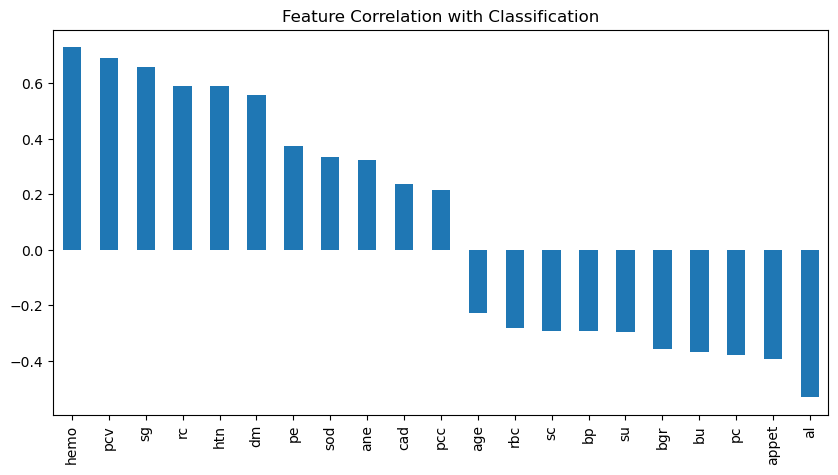

In [389]:
top_features.plot(kind='bar', figsize=(10, 5), title='Feature Correlation with Classification')
plt.show()


In [390]:
#We cant remove cols based on less corr it may be usefull in model imporoving since our dataset is on medical except id col
#everything is imp
                           #Model Selection and Training#
                           #wE WILL TRY EACH mODEL AND compare outputs and finalize one model#

In [391]:
#1 Logistic regression

In [392]:
# Drop the target column to get features
X = df.drop(['classification'], axis=1)

# Target column
y = df['classification']


In [393]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [395]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [398]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [399]:
y_pred = logreg.predict(X_test_scaled)


In [400]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , precision_score,recall_score,f1_score
acc_log = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9875

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.97      1.00      0.98        30

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


Confusion Matrix:
 [[49  1]
 [ 0 30]]
Precision: 0.967741935483871
Recall: 1.0
F1 Score: 0.9836065573770492


In [401]:
 #K-NN 

In [402]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Step 1: Initialize and train the model
knn = KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors later
knn.fit(X_train_scaled, y_train)

# Step 2: Predict
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

# Step 3: Evaluate
print("KNN Classifier Results\n" + "-"*30)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))


KNN Classifier Results
------------------------------
Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           1       0.94      1.00      0.97        30

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80


Confusion Matrix:
 [[48  2]
 [ 0 30]]
Precision: 0.9375
Recall: 1.0
F1 Score: 0.967741935483871


In [403]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 1. Initialize and train the model
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# 2. Predict
y_pred_nb = nb.predict(X_test_scaled)
acc_nb = accuracy_score(y_test, y_pred_nb)

# 3. Evaluate
print("Naive Bayes Results\n" + "-"*30)
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))


Naive Bayes Results
------------------------------
Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           1       0.94      1.00      0.97        30

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80


Confusion Matrix:
 [[48  2]
 [ 0 30]]
Precision: 0.9375
Recall: 1.0
F1 Score: 0.967741935483871


In [404]:
#DESCISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 1. Initialize and train the model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

# 2. Predict
y_pred_dt = dt.predict(X_test_scaled)
acc_dt = accuracy_score(y_test, y_pred_dt)

# 3. Evaluate
print("Decision Tree Results\n" + "-"*30)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


Decision Tree Results
------------------------------
Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        50
           1       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80


Confusion Matrix:
 [[50  0]
 [ 2 28]]
Precision: 1.0
Recall: 0.9333333333333333
F1 Score: 0.9655172413793104


In [405]:
#Ensemble methods 
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 1. Initialize and train the model
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)

# 2. Predict
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

# 3. Evaluate
print("Random Forest Results\n" + "-"*30)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest Results
------------------------------
Accuracy: 0.9625

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        50
           1       1.00      0.90      0.95        30

    accuracy                           0.96        80
   macro avg       0.97      0.95      0.96        80
weighted avg       0.96      0.96      0.96        80


Confusion Matrix:
 [[50  0]
 [ 3 27]]
Precision: 1.0
Recall: 0.9
F1 Score: 0.9473684210526315


In [406]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 1. Initialize and train the model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# 2. Predict
y_pred_gb = gb_model.predict(X_test_scaled)
acc_gb = accuracy_score(y_test, y_pred_gb)

# 3. Evaluate
print("Gradient Boosting Results\n" + "-"*40)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))


Gradient Boosting Results
----------------------------------------
Accuracy: 0.9625

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        50
           1       1.00      0.90      0.95        30

    accuracy                           0.96        80
   macro avg       0.97      0.95      0.96        80
weighted avg       0.96      0.96      0.96        80


Confusion Matrix:
 [[50  0]
 [ 3 27]]
Precision: 1.0
Recall: 0.9
F1 Score: 0.9473684210526315


In [407]:
#ADAboost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 1. Initialize and train
ada_model = AdaBoostClassifier()
ada_model.fit(X_train, y_train)

# 2. Predict
y_pred = ada_model.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred)

# 3. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Confusion Matrix:
 [[50  0]
 [ 0 30]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [409]:
#ANN
from sklearn.neural_network import MLPClassifier

# 1. Initialize and train
ann_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
ann_model.fit(X_train_scaled, y_train)

# 2. Predict
y_pred = ann_model.predict(X_test_scaled)
acc_ann = accuracy_score(y_test, y_pred)
acc_svm = accuracy_score(y_test, y_pred)

# 3. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Confusion Matrix:
 [[50  0]
 [ 0 30]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [410]:
#SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 1. Initialize and train
svm_model = SVC(kernel='rbf')  # You can try 'linear', 'poly', 'sigmoid' too
svm_model.fit(X_train_scaled, y_train)

# 2. Predict
y_pred = svm_model.predict(X_test_scaled)

# 3. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Confusion Matrix:
 [[50  0]
 [ 0 30]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [411]:
#letscompare each model

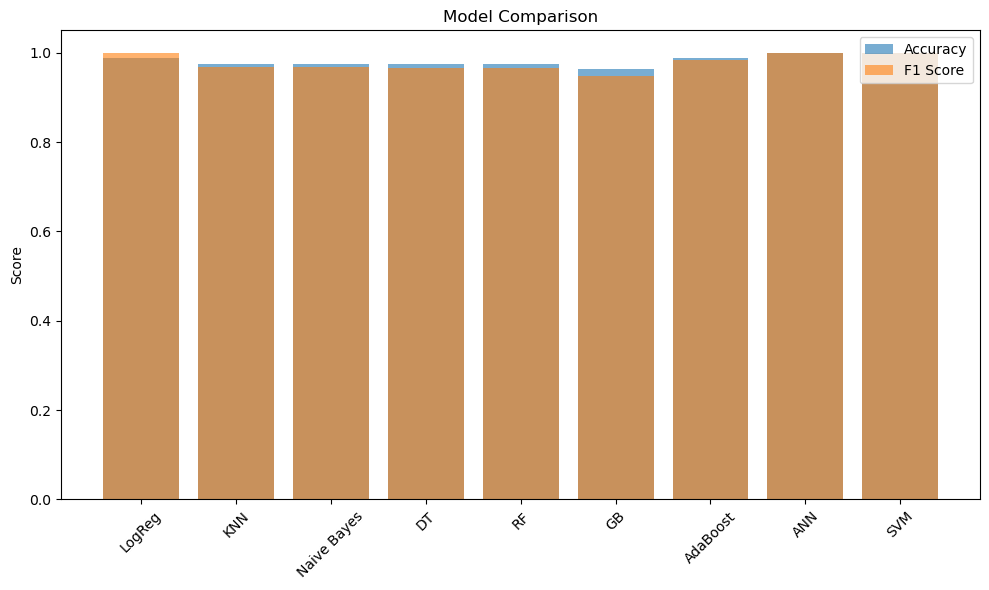

In [412]:
import matplotlib.pyplot as plt

models = ['LogReg', 'KNN', 'Naive Bayes', 'DT', 'RF', 'GB', 'AdaBoost', 'ANN', 'SVM']
accuracies = [0.9875, 0.975, 0.975, 0.975, 0.975, 0.9625, 0.9875, 1.0, 1.0]
f1_scores = [1.0, 0.968, 0.968, 0.966, 0.966, 0.947, 0.983, 1.0, 1.0]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, alpha=0.6, label='Accuracy')
plt.bar(models, f1_scores, alpha=0.6, label='F1 Score')
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [413]:
       #CROSS VALIDATION FOR EACH #

In [414]:
from sklearn.model_selection import train_test_split

# Split your dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [415]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np

pipeline = make_pipeline(StandardScaler(), SVC())

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))


Cross-Validation Scores: [1.       1.       0.984375 1.       1.      ]
Mean CV Accuracy: 0.996875


In [416]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

# Define models in dictionary
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM (RBF)': SVC(kernel='rbf', C=1, gamma=0.1),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'ANN (MLP)': MLPClassifier(max_iter=1000)
}

# Loop and perform CV
cv_results = {}

for name, model in models.items():
    pipeline = make_pipeline(StandardScaler(), model)
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = np.mean(scores)
    cv_results[name] = mean_score
    print(f"{name}: CV Mean Accuracy = {mean_score:.4f}")


Logistic Regression: CV Mean Accuracy = 0.9938
KNN: CV Mean Accuracy = 0.9656
Decision Tree: CV Mean Accuracy = 0.9750
Random Forest: CV Mean Accuracy = 0.9938
Naive Bayes: CV Mean Accuracy = 0.9625
SVM (RBF): CV Mean Accuracy = 0.9969
Gradient Boosting: CV Mean Accuracy = 0.9812
AdaBoost: CV Mean Accuracy = 0.9938
ANN (MLP): CV Mean Accuracy = 0.9938


In [417]:
#from above svm has best cv rate so we finalize it

In [418]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Define pipeline
svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC()
)

# Define hyperparameter grid
param_grid = {
    'svc__C': [0.01, 0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svc__kernel': ['rbf']  # can add 'linear' if you want to test it too
}

# Perform Grid Search
grid = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# Best results
print(" Best Parameters:", grid.best_params_)
print(" Best CV Accuracy:", grid.best_score_)


 Best Parameters: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
 Best CV Accuracy: 0.996875


In [420]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create pipeline with best hyperparams
final_model = make_pipeline(
    StandardScaler(),
    SVC(C=1, gamma=0.1, kernel='rbf')  # from your earlier tuning
)

# Train on full training set
final_model.fit(X_train, y_train)

# Predict on test set
y_pred = final_model.predict(X_test)

# Evaluation
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Confusion Matrix:
 [[50  0]
 [ 0 30]]


In [421]:
import joblib

# Save the full pipeline with scaler + model
joblib.dump(final_model, 'svm_classifier_pipeline.pkl')
print("✅ Model saved as 'svm_classifier_pipeline.pkl'")


✅ Model saved as 'svm_classifier_pipeline.pkl'


In [423]:
import pandas as pd
import joblib

# Load the saved pipeline
final_model = joblib.load("svm_classifier_pipeline.pkl")

# Feature names (make sure order matches what was used during training)
feature_names = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba',
                 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc',
                 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

# Sample input: values must be already encoded (not raw strings)
sample_input = [[35, 70, 1.025, 0, 0, 0, 0, 1, 1,
                 110, 25, 0.8, 140, 4.5, 15.5, 44, 8000, 5.0,
                 1, 1, 1, 0, 1, 1]]  # <- all encoded values

# Create DataFrame for prediction
input_df = pd.DataFrame(sample_input, columns=feature_names)

# Predict
prediction = final_model.predict(input_df)
print("Prediction:", prediction)


Prediction: [1]


In [425]:
import pandas as pd
import joblib

# Load the trained pipeline
final_model = joblib.load("svm_classifier_pipeline.pkl")

# Features (make sure these match training order exactly)
feature_names = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba',
                 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc',
                 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

# 👇 You can change this to test new cases
test_inputs = [
    # 0 = CKD, 1 = not CKD (as per your encoding)
    [45, 80, 1.020, 1, 0, 0, 0, 1, 1, 140, 30, 1.2, 135, 4.2, 13.5, 40, 8200, 4.8, 1, 1, 1, 0, 1, 1],  # Likely not CKD
    [65, 70, 1.010, 3, 2, 1, 1, 0, 0, 180, 60, 2.6, 120, 5.0, 9.5, 30, 11000, 3.0, 0, 0, 0, 1, 0, 0]   # Likely CKD
]

# Create DataFrame
input_df = pd.DataFrame(test_inputs, columns=feature_names)

# Make predictions
predictions = final_model.predict(input_df)

# Show results
for i, pred in enumerate(predictions):
    status = "CKD (0)" if pred == 0 else "Not CKD (1)"
    print(f"Input {i+1} Prediction: {status}")


Input 1 Prediction: Not CKD (1)
Input 2 Prediction: CKD (0)
